# Supplementary Materials A: Notebook for replicating results

This notebook details the creation of two indicators of corrective culture (engagement and organisational learning) based on healthcare organisations responses to patient feedback posted on the website Care Opinion. The measure was developed in three parts:

1. Manual coding of engagement and organisational learning:

This section details six rounds of training two coders (with MSc level in psychology) for scoring engagement and organisational learning in responses to feedback. These rounds were used to align coders understanding of the concepts and adjust the codebook following deliberations about disagreements. It also provides the results of a final round of coding (done blind) where coders scored 600 feedback-response pairs, 200 of which were shared and used to calculate inter-rater reliability.

2. Classifier development: 

This section details the development of a text classifier for automatically identifying engagement and organisational learning using the manually coded data from the previous section. The text classifier works by sending a prompt to a Large Language Model (LLM) alongside the target feedback-response pair to return a score for engagement and organisational learning. We used 30% (n = 180) of the data for adjusting the prompt across eight iterations with the goal of maximising the evaluation metrics. Once satisfied with the prompt, we tested it on the remaining 70% (n = 420) of the manually coded data. We compared the performance of three LLMs: GPT-5 (High Reasoning), GPT-5-mini (High Reasoning) and GPT-5-mini (Low Reasoning). Following this, we used the final prompt to score the full dataset of feedback-response pairs (n = 157,051).

3. External evaluation: 

Once coded, we used the resulting dataset to investigate whether engagement and organisational learning correlate with the NHS England Staff Survey. We report descriptive statistics, correlations, and a mixed effects regression. 

This notebook is thus organised across these three stages of analysis.

## Set up

In [79]:
# General purpose packages
import pandas as pd
import numpy as np
import math

from itertools import combinations
import re

import warnings
warnings.filterwarnings('ignore')

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# running the IRR statistics
import krippendorff
import pingouin as pg

# For LLM classifier
from pydantic import BaseModel, Field
from openai import OpenAI

# For various statistics
from scipy import stats
from scipy.stats import pearsonr, spearmanr,chi2

# Evaluation metrics for classifiers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, matthews_corrcoef, confusion_matrix, 
    mean_absolute_error, cohen_kappa_score
)
from scipy.stats import spearmanr, kendalltau

### ALTERNATIVE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, cohen_kappa_score

# For running the mixed effects models
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

Below defines the functions used in the analysis.

In [85]:
# ~~~~~~~~~~~~~~~ FUNCTIONS FOR INTER-RATER RELIABILITY

def gwet_ac1_binary(c1, c2):
    """
    Computes Gwet's AC1 
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()

    if df.empty or df.nunique().max() <= 1:
        return np.nan
    Po = (df["c1"] == df["c2"]).mean()
    p = (df["c1"].mean() + df["c2"].mean()) / 2
    Pe = 2 * p * (1 - p)

    if Pe >= 1:
        return np.nan

    return (Po - Pe) / (1 - Pe)

def percent_agreement(c1, c2):
    mask = c1.notna() & c2.notna()
    if mask.sum() == 0:
        return np.nan
    return (c1[mask] == c2[mask]).mean() * 100\

def is_not_coded(c1, c2):
    combined = pd.concat([c1, c2]).dropna()
    return combined.nunique() <= 1

def bootstrap_ci_krippendorff(c1, c2, n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate bootstrap confidence interval for Krippendorff's alpha.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"alpha": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Original alpha
    alpha_orig = krippendorff.alpha(
        reliability_data=np.vstack([df["c1"], df["c2"]]),
        level_of_measurement="nominal"
    )
    
    # Bootstrap samples
    bootstrap_alphas = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices].values
        c2_boot = df["c2"].iloc[indices].values
        
        try:
            alpha_boot = krippendorff.alpha(
                reliability_data=np.vstack([c1_boot, c2_boot]),
                level_of_measurement="nominal"
            )
            if not np.isnan(alpha_boot):
                bootstrap_alphas.append(alpha_boot)
        except:
            continue
    
    if len(bootstrap_alphas) == 0:
        return {"alpha": alpha_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_alphas, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_alphas, alpha_upper * 100)
    
    return {
        "alpha": alpha_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

def bootstrap_ci_weighted_kappa(c1, c2, weights='quadratic', n_bootstrap=1000, 
                                confidence=0.95, random_state=None, labels=None):
    """
    Calculate bootstrap confidence interval for weighted kappa.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"kappa": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Determine labels if not provided
    if labels is None:
        # Get all unique values from both raters
        all_values = pd.concat([df["c1"], df["c2"]]).unique()
        labels = sorted(all_values)
    
    # Original kappa with suppressed warnings
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=UserWarning)
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        try:
            kappa_orig = cohen_kappa_score(df["c1"], df["c2"], weights=weights, labels=labels)
        except:
            kappa_orig = np.nan
    
    # Bootstrap samples
    bootstrap_kappas = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices]
        c2_boot = df["c2"].iloc[indices]
        
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=UserWarning)
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            try:
                kappa_boot = cohen_kappa_score(c1_boot, c2_boot, weights=weights, labels=labels)
                if not np.isnan(kappa_boot):
                    bootstrap_kappas.append(kappa_boot)
            except:
                continue
    
    if len(bootstrap_kappas) == 0:
        return {"kappa": kappa_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_kappas, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_kappas, alpha_upper * 100)
    
    return {
        "kappa": kappa_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

def bootstrap_ci_gwet_ac1(c1, c2, n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate bootstrap confidence interval for Gwet's AC1.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"AC1": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Original AC1
    ac1_orig = gwet_ac1_binary(df["c1"], df["c2"])
    
    # Bootstrap samples
    bootstrap_ac1s = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices]
        c2_boot = df["c2"].iloc[indices]
        
        ac1_boot = gwet_ac1_binary(c1_boot, c2_boot)
        if not np.isnan(ac1_boot):
            bootstrap_ac1s.append(ac1_boot)
    
    if len(bootstrap_ac1s) == 0:
        return {"AC1": ac1_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_ac1s, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_ac1s, alpha_upper * 100)
    
    return {
        "AC1": ac1_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }


def irr_binary_by_round(df, vars, round_col="Round", coder_suffixes=("C1", "C2"),
                        n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate inter-rater reliability for binary variables by round with CIs.
    """
    rows = []

    for rnd, df_rnd in df.groupby(round_col):
        for var in vars:
            c1 = df_rnd[f"{var}_{coder_suffixes[0]}"]
            c2 = df_rnd[f"{var}_{coder_suffixes[1]}"]

            if is_not_coded(c1, c2):
                rows.append({
                    "Round": rnd,
                    "Variable": var,
                    "Krippendorff_alpha": np.nan,
                    "Krippendorff_CI_lower": np.nan,
                    "Krippendorff_CI_upper": np.nan,
                    "Gwet_AC1": np.nan,
                    "Gwet_CI_lower": np.nan,
                    "Gwet_CI_upper": np.nan,
                    "Agreement_pct": np.nan,
                    "Status": "Not coded"
                })
                continue

            # Calculate Krippendorff's alpha with CI
            alpha_result = bootstrap_ci_krippendorff(
                c1, c2, 
                n_bootstrap=n_bootstrap, 
                confidence=confidence, 
                random_state=random_state
            )

            # Calculate Gwet's AC1 with CI
            ac1_result = bootstrap_ci_gwet_ac1(
                c1, c2,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                random_state=random_state
            )
            
            agreement = percent_agreement(c1, c2)

            rows.append({
                "Round": rnd,
                "Variable": var,
                "Krippendorff_alpha": alpha_result["alpha"],
                "Krippendorff_CI_lower": alpha_result["CI_lower"],
                "Krippendorff_CI_upper": alpha_result["CI_upper"],
                "Gwet_AC1": ac1_result["AC1"],
                "Gwet_CI_lower": ac1_result["CI_lower"],
                "Gwet_CI_upper": ac1_result["CI_upper"],
                "Agreement_pct": agreement,
                "Status": "Coded"
            })

    return pd.DataFrame(rows)


# Your existing bootstrap functions
def bootstrap_ci_krippendorff(c1, c2, n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate bootstrap confidence interval for Krippendorff's alpha.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"alpha": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Original alpha
    alpha_orig = krippendorff.alpha(
        reliability_data=np.vstack([df["c1"], df["c2"]]),
        level_of_measurement="nominal"
    )
    
    # Bootstrap samples
    bootstrap_alphas = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices].values
        c2_boot = df["c2"].iloc[indices].values
        
        try:
            alpha_boot = krippendorff.alpha(
                reliability_data=np.vstack([c1_boot, c2_boot]),
                level_of_measurement="nominal"
            )
            if not np.isnan(alpha_boot):
                bootstrap_alphas.append(alpha_boot)
        except:
            continue
    
    if len(bootstrap_alphas) == 0:
        return {"alpha": alpha_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_alphas, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_alphas, alpha_upper * 100)
    
    return {
        "alpha": alpha_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

def icc_3k_ordinal(df, var, coder_suffixes=("C1", "C2")):
    """
    Computes ICC(3,k) for a single ordinal variable with detailed statistics.
    """
    c1 = df[f"{var}_{coder_suffixes[0]}"]
    c2 = df[f"{var}_{coder_suffixes[1]}"]
    
    # Remove missing values
    df_clean = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df_clean.empty or len(df_clean) < 2:
        return {
            "ICC3k": np.nan,
            "CI95%": (np.nan, np.nan),
            "pval": np.nan
        }
    
    # Reshape to long format for ICC
    data_long = pd.DataFrame({
        'subject': list(range(len(df_clean))) * 2,
        'rater': ['C1'] * len(df_clean) + ['C2'] * len(df_clean),
        'rating': pd.concat([df_clean['c1'], df_clean['c2']]).values
    })
    
    try:
        icc_results = pg.intraclass_corr(
            data=data_long,
            targets='subject',
            raters='rater',
            ratings='rating'
        )
        
        # Extract ICC3k row (two-way mixed, consistency, average measures)
        icc3k_row = icc_results[icc_results['Type'] == 'ICC3k']
        
        if not icc3k_row.empty:
            return {
                "ICC3k": icc3k_row['ICC'].values[0],
                "CI95%": (icc3k_row['CI95%'].values[0][0], icc3k_row['CI95%'].values[0][1]),
                "pval": icc3k_row['pval'].values[0]
            }
        else:
            return {
                "ICC3k": np.nan,
                "CI95%": (np.nan, np.nan),
                "pval": np.nan
            }
    except Exception as e:
        return {
            "ICC3k": np.nan,
            "CI95%": (np.nan, np.nan),
            "pval": np.nan
        }

# ENHANCED: IRR for ordinal variables including Weighted Kappa
def irr_ordinal_by_round(df, vars, round_col="Round", coder_suffixes=("C1", "C2"),
                         kappa_weights='quadratic', n_bootstrap=1000, 
                         confidence=0.95, random_state=None):
    """
    Calculate inter-rater reliability for ordinal variables by round.
    Now includes weighted kappa alongside ICC.
    """
    rows = []

    for rnd, df_rnd in df.groupby(round_col):
        for var in vars:
            c1 = df_rnd[f"{var}_{coder_suffixes[0]}"]
            c2 = df_rnd[f"{var}_{coder_suffixes[1]}"]

            if is_not_coded(c1, c2):
                rows.append({
                    "Round": rnd,
                    "Variable": var,
                    "ICC_3k": np.nan,
                    "ICC_CI_lower": np.nan,
                    "ICC_CI_upper": np.nan,
                    "ICC_pval": np.nan,
                    "Weighted_kappa": np.nan,
                    "Kappa_CI_lower": np.nan,
                    "Kappa_CI_upper": np.nan,
                    "Agreement_pct": np.nan,
                    "Status": "Not coded"
                })
                continue

            # Calculate ICC(3,k) with confidence intervals and p-value
            res = icc_3k_ordinal(df_rnd, var, coder_suffixes=coder_suffixes)
            
            # Calculate Weighted Kappa with CI
            kappa_result = bootstrap_ci_weighted_kappa(
                c1, c2,
                weights=kappa_weights,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                random_state=random_state
            )
            
            agreement = percent_agreement(c1, c2)

            rows.append({
                "Round": rnd,
                "Variable": var,
                "ICC_3k": res['ICC3k'],
                "ICC_CI_lower": res['CI95%'][0],
                "ICC_CI_upper": res['CI95%'][1],
                "ICC_pval": res['pval'],
                "Weighted_kappa": kappa_result["kappa"],
                "Kappa_CI_lower": kappa_result["CI_lower"],
                "Kappa_CI_upper": kappa_result["CI_upper"],
                "Agreement_pct": agreement,
                "Status": "Coded"
            })

    return pd.DataFrame(rows)

def _round_to_int(round_str):
    """Convert 'Round_3' -> 3"""
    return int(re.search(r"\d+", round_str).group())


def get_disagreements_summary(df, vars, round_col="Round", 
                             coder_suffixes=("C1", "C2"),
                             var_name_dict=None,
                             var_type_dict=None,
                             by_round=True):
    """
    Create a dataframe summarizing disagreements between coders.
    """
    results = []
    
    if by_round:
        # Group by round
        for rnd, df_rnd in df.groupby(round_col):
            for var in vars:
                stats = _calculate_disagreements(df_rnd, var, coder_suffixes)
                if stats is not None:
                    stats['Round'] = rnd
                    stats['Variable'] = var_name_dict.get(var, var) if var_name_dict else var
                    stats['Variable_Type'] = var_type_dict.get(var, "") if var_type_dict else ""
                    results.append(stats)
    else:
        # Aggregate across all rounds
        for var in vars:
            stats = _calculate_disagreements(df, var, coder_suffixes)
            if stats is not None:
                stats['Variable'] = var_name_dict.get(var, var) if var_name_dict else var
                stats['Variable_Type'] = var_type_dict.get(var, "") if var_type_dict else ""
                results.append(stats)
    
    # Create dataframe and reorder columns
    if results:
        summary_df = pd.DataFrame(results)
        if by_round:
            col_order = ['Round', 'Variable', 'Variable_Type', 'N_Coded', 'N_Disagreements', 'Pct_Disagreements']
        else:
            col_order = ['Variable', 'Variable_Type', 'N_Coded', 'N_Disagreements', 'Pct_Disagreements']
        summary_df = summary_df[col_order]
        #summary_df['Round'] = summary_df['Round'].apply(_round_to_int)
    else:
        summary_df = pd.DataFrame()
    return summary_df


def _calculate_disagreements(df, var, coder_suffixes):
    """
    Helper function to calculate disagreement statistics for a single variable.
    """
    c1_col = f"{var}_{coder_suffixes[0]}"
    c2_col = f"{var}_{coder_suffixes[1]}"
    
    if c1_col not in df.columns or c2_col not in df.columns:
        return None
    
    c1 = df[c1_col]
    c2 = df[c2_col]
    
    # Find disagreements
    mask = c1.notna() & c2.notna()
    disagreements = mask & (c1 != c2)
    n_disagreements = disagreements.sum()
    n_coded = mask.sum()
    
    if n_coded == 0:
        pct_disagreements = None
    else:
        pct_disagreements = round((n_disagreements / n_coded) * 100, 1)
    
    return {
        'N_Coded': n_coded,
        'N_Disagreements': n_disagreements,
        'Pct_Disagreements': pct_disagreements
    }


def plot_disagreement_stacked_bar(df, figsize=(14, 8), color_palette='tab20'):
    """
    Create a stacked barplot showing percentage of disagreements across variables per round.
    """
    
    # Pivot the data to have rounds as index and variables as columns
    pivot_df = df.pivot(index='Round', 
                        columns='Variable', 
                        values='Pct_Disagreements')
    
    # Sort the rounds properly (assuming format 'Round_X')
    round_order = sorted(pivot_df.index, 
                        key=lambda x: int(x.split('_')[1]))
    pivot_df = pivot_df.reindex(round_order)
    
    # Get unique variables and assign colors
    variables = pivot_df.columns
    n_vars = len(variables)
    
    if isinstance(color_palette, str):
        colors = plt.cm.get_cmap(color_palette)(np.linspace(0, 1, n_vars))
    else:
        colors = color_palette[:n_vars]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the stacked bar plot
    bottom = np.zeros(len(pivot_df))
    bars = []
    
    for i, var in enumerate(variables):
        values = pivot_df[var].fillna(0)  # Fill NaN with 0 if any
        bar = ax.bar(range(len(pivot_df)), 
                     values, 
                     bottom=bottom,
                     label=var,
                     color=colors[i],
                     edgecolor='white',
                     linewidth=0.5)
        bars.append(bar)
        bottom += values
    
    # Customize the plot
    ax.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage of Disagreements (%)', fontsize=12, fontweight='bold')
    ax.set_title('Percentage of Disagreements Across Variables by Round', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), 
              loc='upper left', 
              ncol=1,
              frameon=True,
              fancybox=True,
              shadow=True,
              title='Variables',
              title_fontsize=11,
              fontsize=9)
    
    # Add value labels on the bars (optional - comment out if too cluttered)
    for bars_group in bars:
        for bar in bars_group:
            height = bar.get_height()
            if height > 0.5:  # Only show label if percentage is > 0.5
                ax.text(bar.get_x() + bar.get_width()/2., 
                       bar.get_y() + height/2.,
                       f'{height:.1f}',
                       ha='center', 
                       va='center',
                       fontsize=8,
                       color='white',
                       fontweight='bold')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig, ax
def create_subplot_figure(plot_configs, nrows=1, ncols=2, figsize=(16, 6), 
                          share_legend=True, suptitle=None):
    """
    Create a figure with multiple subplots using plot_agreement_by_round.
    """
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    # Plot each config
    for i, config in enumerate(plot_configs):
        if i >= len(axes_flat):
            break
        
        # Set legend visibility
        if share_legend:
            config['show_legend'] = (i == len(plot_configs) - 1)
            config['legend_loc'] = 'outside'
        
        config['ax'] = axes_flat[i]
        plot_agreement_by_round(**config)
    
    # Hide unused subplots
    for j in range(len(plot_configs), len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig, axes


def plot_agreement_by_round(df, y_col, figsize=(12, 6), variable_order=None, 
                            variable_labels=None, show_values=True, colormap='viridis', 
                            title=None, value_fontsize=8, ci_lower_col=None, 
                            ci_upper_col=None, show_ci=True, xlabel='Variable', 
                            ylabel=None, ylim=None, ax=None, show_legend=True, 
                            legend_loc='outside'):
    """
    Create a grouped bar chart with Variables on x-axis and agreement bars for each Round.
    """
    
    # Create figure if ax not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    
    # Get unique variables and rounds
    if variable_order is None:
        variables = df['Variable'].unique()
    else:
        unique_vars = set(df['Variable'].unique())
        variables = [var for var in variable_order if var in unique_vars]
    
    # Create display labels
    if variable_labels is None:
        display_labels = list(variables)
    else:
        display_labels = [variable_labels.get(var, var) for var in variables]
    
    # Sort rounds naturally
    def extract_round_num(round_str):
        try:
            return int(round_str.split('_')[1])
        except:
            return round_str
    
    rounds = sorted(df['Round'].unique(), key=extract_round_num)
    
    # Set up plot parameters
    n_vars = len(variables)
    n_rounds = len(rounds)
    bar_width = 0.8 / n_rounds
    x_positions = np.arange(n_vars)
    cmap = plt.cm.get_cmap(colormap)
    colors = cmap(np.linspace(0.3, 0.9, n_rounds))
    
    # Plot bars for each round
    for i, round_name in enumerate(rounds):
        round_data = df[df['Round'] == round_name]
        values = []
        ci_lower = []
        ci_upper = []
        
        for var in variables:
            var_data = round_data[round_data['Variable'] == var]
            if len(var_data) > 0:
                values.append(var_data[y_col].values[0])
                if ci_lower_col and ci_upper_col and show_ci:
                    ci_lower.append(var_data[ci_lower_col].values[0])
                    ci_upper.append(var_data[ci_upper_col].values[0])
            else:
                values.append(np.nan)
                if ci_lower_col and ci_upper_col and show_ci:
                    ci_lower.append(np.nan)
                    ci_upper.append(np.nan)
        
        offset = (i - n_rounds/2 + 0.5) * bar_width
        
        yerr = None
        if ci_lower_col and ci_upper_col and show_ci:
            yerr = [np.array(values) - np.array(ci_lower), 
                    np.array(ci_upper) - np.array(values)]
        
        round_label = round_name.replace('_', ' ')
        
        bars = ax.bar(x_positions + offset, values, bar_width, 
                      label=round_label, color=colors[i],
                      edgecolor='black', linewidth=0.5,
                      yerr=yerr, capsize=2 if yerr else 0,
                      error_kw={'elinewidth': 1, 'capthick': 1})
        
        if show_values:
            for j, (bar, val) in enumerate(zip(bars, values)):
                if not np.isnan(val):
                    label_y = bar.get_height()
                    if yerr is not None and not np.isnan(ci_upper[j]):
                        label_y = ci_upper[j]
                    offset_y = 2 if df[y_col].max() > 1.5 else 0.02
                    ax.text(bar.get_x() + bar.get_width()/2, label_y + offset_y,
                           f'{val:.1f}', ha='center', va='bottom', 
                           fontsize=value_fontsize, rotation=90)
    
    # Customize the plot
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel if ylabel else y_col, fontsize=12, fontweight='bold')
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_labels, fontweight='bold')
    
    # Auto-detect y-axis limits
    if ylim:
        ax.set_ylim(ylim)
    else:
        max_val = df[y_col].max()
        min_val = df[y_col].min()
        if max_val > 1.5:
            ax.set_ylim(0, 110)
            ax.set_yticks(np.arange(0, 110, 10))
        else:
            y_min = min(-0.1, min_val - 0.1)
            ax.set_ylim(y_min, 1.15)
            ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
        else:
            ax.legend(loc=legend_loc)
    
    return fig, ax

# ~~~~~~~~~~ FUNCTIONS FOR EVALUATING CLASSIFIERS / PRINTING EXAMPLES
def evaluate_binary_classifier(y_true, y_pred, name=None, iteration=None):
    """
    Evaluate binary classification performance.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {'name': name,'iteration':iteration,'n': len(y_true),
            'accuracy': accuracy,'precision': precision,'recall': recall,
            'f1': f1,'mcc': mcc,'tp': tp,'tn': tn,'fp': fp,'fn': fn
    }
    
def evaluate_ordinal_classifier(y_true, y_pred, classes=None, name=None, iteration=None):
    """
    Evaluate ordinal classification performance.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if classes is None:
        try:
            unique = np.unique(np.concatenate([y_true, y_pred])).astype(float)
            classes = sorted(unique, key=float)
            classes = [int(x) if float(x).is_integer() else float(x) for x in classes]
        except Exception:
            classes = sorted(list(set(np.concatenate([y_true, y_pred]))))
    label_to_idx = {lab: i for i, lab in enumerate(classes)}
    y_true_enc = np.array([label_to_idx[v] for v in y_true])
    y_pred_enc = np.array([label_to_idx[v] for v in y_pred])
    accuracy = accuracy_score(y_true_enc, y_pred_enc)
    mae = mean_absolute_error(y_true_enc, y_pred_enc)
    within1_acc = np.mean(np.abs(y_true_enc - y_pred_enc) <= 1)
    kappa_linear = cohen_kappa_score(y_true_enc, y_pred_enc, weights="linear")
    spearman_r, spearman_p = spearmanr(y_true_enc, y_pred_enc)
    kendall_tau, kendall_p = kendalltau(y_true_enc, y_pred_enc)
    return {'name': name,'iteration':iteration,'n': len(y_true),
                'classes': classes,'accuracy': accuracy,'mae': mae,
                'within_1_acc': within1_acc,'kappa_linear': kappa_linear,
                'spearman_r': spearman_r,'spearman_p': spearman_p,
                'kendall_tau': kendall_tau, 'kendall_p': kendall_p
    }


def plot_grouped_accuracy(df, figsize=(16, 6), name_order=None, show_values=True,
                         colormap='viridis', title=None, value_fontsize=8, metric = 'accuracy', ylabel = 'Accuracy'):
    """
    Create a grouped bar chart with names on x-axis and metric bars for each iteration
    """
    
    
    # Get unique names and iterations
    if name_order is None:
        names = df['name'].unique()
    else:
        unique_names = set(df['name'].unique())
        provided_names = set(name_order)
        names = [name for name in name_order if name in unique_names]
        
    iterations = sorted(df['iteration'].unique())
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    n_names = len(names)
    n_iterations = len(iterations)
    bar_width = 0.8 / n_iterations  # Width of each bar
    x_positions = np.arange(n_names)  # Base positions for each name
    cmap = plt.cm.get_cmap(colormap)
    colors = cmap(np.linspace(0.3, 0.9, n_iterations))
    
    # Plot bars for each iteration
    for i, iteration in enumerate(iterations):
        iteration_data = df[df['iteration'] == iteration]
        accuracies = []
        for name in names:
            name_data = iteration_data[iteration_data['name'] == name][metric].values
            if len(name_data) > 0:
                accuracies.append(name_data[0])
            else:
                accuracies.append(0)  # Default to 0 if no data
        offset = (i - n_iterations/2 + 0.5) * bar_width
        bars = ax.bar(x_positions + offset, accuracies, bar_width, 
                      label=f'Iteration {iteration}', color=colors[i],
                      edgecolor='black', linewidth=0.5)
        # Add value labels on top of bars
        if show_values:
            for bar, accuracy in zip(bars, accuracies):
                if accuracy > 0:  # Only label if there's a value
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{accuracy:.2f}', ha='center', va='bottom', 
                           fontsize=value_fontsize)
    
    # Customize the plot
    ax.set_xlabel(' ', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(names, fontweight = "bold")
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
    plt.tight_layout()
    return fig, ax


def compare_classifiers_mixed_variables(df, classifier_names, var_config, 
                                       metric='accuracy'):
    """
    Compare classifier performance across mixed binary and ordinal variables.
    """
    # Identify ground truth variables (those ending with '_true')
    ground_truth_cols = [col for col in df.columns if col.endswith('_true')]
    base_vars = [col[:-5] for col in ground_truth_cols]  # Remove '_true' suffix
    
    available_predictions = []
    for var in base_vars:
        for clf in classifier_names:
            pred_col = f"gpt_{var}_{clf}"
            # Make sure it's not a Reasoning or Quote column
            if pred_col in df.columns and not any(x in pred_col for x in ['Reasoning', 'Quote']):
                available_predictions.append((var, clf, pred_col))
    if var_config == 'auto':
        var_config = {}
        for var in base_vars:
            gt_col = f"{var}_true"
            if gt_col in df.columns:
                n_unique = df[gt_col].nunique()
                if n_unique == 2:
                    var_config[var] = 'binary'
                elif n_unique > 2:
                    var_config[var] = 'ordinal'
                binary_vars = [v for v, t in var_config.items() if t == 'binary']
        ordinal_vars = [v for v, t in var_config.items() if t == 'ordinal']
    # Step 1: Calculate metrics for each variable-classifier combination
    results = []
    successful_vars = set()
    for var, var_type in var_config.items():
        # Ground truth column
        gt_col = f"{var}_true"
        if gt_col not in df.columns:
            continue
        y_true = df[gt_col]
        for clf in classifier_names:
            # Prediction column: gpt_{variable}_{classifier}
            pred_col = f"gpt_{var}_{clf}"
            if pred_col not in df.columns:
                continue
            y_pred = df[pred_col]
            mask = ~(y_true.isna() | y_pred.isna())
            y_true_clean = y_true[mask]
            y_pred_clean = y_pred[mask]
            if len(y_true_clean) == 0:
                continue
            # Calculate metrics based on variable type
            if var_type == 'binary':
                metrics = evaluate_binary_classifier(y_true_clean, y_pred_clean)
            else:  # ordinal
                metrics = evaluate_ordinal_classifier(y_true_clean, y_pred_clean)
            if metric not in metrics:
                # Use accuracy as fallback
                metric_value = metrics.get('accuracy', np.nan)
            else:
                metric_value = metrics[metric]
            results.append({'variable': var,'var_type': var_type,'classifier': clf,
                            'metric_value': metric_value,'n_samples': metrics['n']
            })
            successful_vars.add(var)
    
    results_df = pd.DataFrame(results)
    
    # Reshape data for Friedman test
    pivot_df = results_df.pivot(index='variable', 
                                columns='classifier', 
                                values='metric_value')
        
    print(f"\nMean {metric} across all variables:")
    print(pivot_df.mean().sort_values(ascending=False).round(4))
    pivot_df_clean = pivot_df.dropna()
    
    if len(pivot_df_clean) < len(pivot_df):
        print(f"\nNote: Dropped {len(pivot_df) - len(pivot_df_clean)} variables with missing values")
    
    if len(pivot_df_clean) == 0:
        print("\nERROR: No valid data for Friedman test")
        return {
            'summary_stats': pivot_df,
            'results_df': results_df,
            'friedman': None,
            'pairwise': None
        }
    
    friedman_stat, friedman_p = stats.friedmanchisquare(*[pivot_df_clean[clf].values 
                                                          for clf in classifier_names])
    print(f"\n=== Friedman Test (across all {len(pivot_df_clean)} variables) ===")
    print(f"Chi-squared statistic: {friedman_stat:.4f}")
    print(f"p-value: {friedman_p:.4f}")
    if friedman_p < 0.05:
        print("Result: Significant difference found among classifiers (p < 0.05)")
    else:
        print("Result: No significant difference found among classifiers (p >= 0.05)")
    # Post-hoc pairwise comparisons
    print(f"\n=== Pairwise Comparisons (Wilcoxon signed-rank test) ===")
    pairwise_results = []
    for clf1, clf2 in combinations(classifier_names, 2):
        diff = pivot_df_clean[clf1] - pivot_df_clean[clf2]
        try:
            wilcox_stat, wilcox_p = stats.wilcoxon(diff, alternative='two-sided')
        except:
            wilcox_stat, wilcox_p = np.nan, 1.0
        mean_diff = diff.mean()
        pairwise_results.append({'comparison': f"{clf1} vs {clf2}",'mean_diff': mean_diff,
                                 'wilcoxon_p': wilcox_p,'significant': wilcox_p < 0.05
        })
        print(f"\n{clf1} vs {clf2}:")
        print(f"  Mean difference: {mean_diff:.4f}")
        print(f"  p-value: {wilcox_p:.4f}")
        if wilcox_p < 0.05:
            winner = clf1 if mean_diff > 0 else clf2
            print(f"  Result: {winner} is significantly better")
        else:
            print(f"  Result: No significant difference")
    # Bonferroni correction
    n_comparisons = len(pairwise_results)
    bonferroni_alpha = 0.05 / n_comparisons
    print(f"\n=== With Bonferroni Correction (α = {bonferroni_alpha:.4f}) ===")
    for result in pairwise_results:
        if result['wilcoxon_p'] < bonferroni_alpha:
            print(f"{result['comparison']}: Significant (p={result['wilcoxon_p']:.4f})")
    return {'summary_stats': pivot_df,'results_df': results_df,
            'friedman': {'statistic': friedman_stat, 'p_value': friedman_p} if len(pivot_df_clean) > 0 else None,'pairwise': pd.DataFrame(pairwise_results) if pairwise_results else None
    }
    
# Print examples of classifications
def print_classification_examples(df, variable, text_cols, category, n_examples=3, pred_suffix = "_miniLow", positive_label = 1):
    true_col = variable + "_true"
    pred_col = "gpt_" + variable + pred_suffix
    quote_col = "gpt_" + variable + "Quote" + pred_suffix 
    reason_col = "gpt_" + variable + "Reasoning" + pred_suffix
    # Define category conditions
    is_positive_true = df[true_col] == positive_label
    is_positive_pred = df[pred_col] == positive_label
    
    category_masks = {
        'TP': is_positive_true & is_positive_pred,      # Actually positive, predicted positive
        'TN': ~is_positive_true & ~is_positive_pred,    # Actually negative, predicted negative
        'FP': ~is_positive_true & is_positive_pred,     # Actually negative, predicted positive
        'FN': is_positive_true & ~is_positive_pred      # Actually positive, predicted negative
    }
    
    filtered_df = df[category_masks[category]].copy()
    try:
        filtered_df = filtered_df.sample(n_examples)
    except:
        pass 
    
    if n_examples is not None and n_examples < len(filtered_df):
        filtered_df = filtered_df.sample(n=n_examples)
        
    for idx, (row_idx, row) in enumerate(filtered_df.iterrows(), 1):
        print(f"Example {idx} (Index: {row_idx})")
        print(f"  True Label: {row[true_col]} | Predicted Label: {row[pred_col]}")
        print()
        
        for col in text_cols:
            print(col)
            print(f"  {row[col]}")
            print()
        
        print(f"GPT Reasoning: {row[reason_col]}")
        print()
        print(f"GPT extracted quote: {row[quote_col]}")
        print(f"\n-------------------\n")

def get_examples(df, score="high", n_quotes = 5):
    df = df[["story_id",
             "engagement","organisationalLearning",
             "engagementQuote","organisationalLearningQuote"]]
    print(f"---\nOnly fetching {n_quotes} {score} scoring examples.\n---")
    if score == "high":
        df = df[(df["engagement"] == 1) & (df["organisationalLearning"] == 1)].copy()
    elif score == "low":
        df = df[(df["engagement"] == 0) & (df["organisationalLearning"] == 0)].copy()
    df = df.sample(n_quotes)
    for i, row in df.iterrows():
        print(f"\n---{row["story_id"]}---")
        print("     Engagement Quote:")
        print(row["engagementQuote"])
        print("     Organisational Learning Quote:")
        print(row["organisationalLearningQuote"])
        
# ~~~~~~~~~ FUNCTIONS FOR DESCRIPTIVE STATISTICS

def summary_stats(df, cols=None):
    """Print summary statistics table for numeric columns"""
    if cols is None:
        cols = df.select_dtypes('number').columns
    
    stats = df[cols].agg(['mean', 'median', 'std', 'min', 'max']).T
    stats.columns = ['Mean', 'Median', 'SD', 'Min', 'Max']
    
    return stats

def histogram_grid(data, columns=None, ncols=3, bins=20, figsize=None,
                   color='steelblue', alpha=0.7, edgecolor='black',
                   title=None, kde=False, stat='count'):
    """
    Create a grid of histograms for multiple variables.
    """
    # Convert to DataFrame if needed
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Select columns
    if columns is None:
        columns = data.select_dtypes(include=[np.number]).columns.tolist()
    else:
        data = data[columns]
    
    n_vars = len(columns)
    
    # Calculate grid dimensions
    nrows = int(np.ceil(n_vars / ncols))
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    # Create figure and axes
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()  # Flatten for easy iteration
    
    # Plot histograms
    for idx, col in enumerate(columns):
        ax = axes[idx]
        
        # Get data and remove NaN
        col_data = data[col].dropna()
        
        # Determine if we need density for KDE
        density = (stat == 'density') or kde
        
        # Plot histogram
        n, bins_edges, patches = ax.hist(
            col_data, 
            bins=bins, 
            color=color,
            alpha=alpha,
            edgecolor=edgecolor,
            density=density
        )
        
        # Overlay KDE if requested
        if kde:
            from scipy import stats
            kde_x = np.linspace(col_data.min(), col_data.max(), 200)
            kde_y = stats.gaussian_kde(col_data)(kde_x)
            ax.plot(kde_x, kde_y, 'r-', linewidth=2, label='KDE')
            ax.legend()
        
        # Customize plot
        ax.set_xlabel(col, fontsize=11, fontweight='bold')
        ax.set_ylabel(stat.capitalize(), fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add statistics text
        stats_text = f'μ={col_data.mean():.2f}\nσ={col_data.std():.2f}\nn={len(col_data)}'
        ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
               fontsize=8)
    
    # Hide extra subplots
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    # Add overall title
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    return fig, axes

# For correlations matrix


def corr_with_sig(df, method = 'spearman'):
    """Print Spearman correlation matrix with significance asterisks."""
    cols = df.columns
    n = len(cols)
    if method == 'spearman':
        corr = df.corr(method='spearman')
    elif method == 'pearson':
        corr = df.corr()
    # Calculate p-values
    pvals = pd.DataFrame(np.ones((n, n)), index=cols, columns=cols)
    for i in range(n):
        for j in range(i+1, n):
            if method == 'spearman':
                _, p = spearmanr(df.iloc[:,i].dropna(), df.iloc[:,j].dropna())
            elif method == 'pearson':
                _, p = spearmanr(df.iloc[:,i].dropna(), df.iloc[:,j].dropna())
            pvals.iloc[i,j] = pvals.iloc[j,i] = p
    
    # Format with asterisks
    def fmt(r, p):
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        return f"{r:.2f}{stars}"
    
    result = corr.copy().astype(str)
    for i in range(n):
        for j in range(n):
            result.iloc[i,j] = fmt(corr.iloc[i,j], pvals.iloc[i,j])
    
    return result

# ~~~~~~~ FUNCTIONS FOR ASSESSING MIXED EFFECTS MODELS
def test_models(df, models_to_test, target = "trust_shmi", groups = "trust_idx"):
    aic_lst = []
    bic_lst = []
    n_params_lst = []
    logLik_lst = []
    coef_dict = {}  
    pval_dict = {} 
    for c in models_to_test:
        formula = f"{target} ~ " + c
        model = sm.MixedLM.from_formula(
            formula=formula,
            data=df,
            re_formula="1",
            groups=groups
        )
        result = model.fit()
        logLik_lst.append(result.llf)
        aic, bic, n_params = calculate_aic_bic(result)
        aic_lst.append(aic)
        bic_lst.append(bic)
        n_params_lst.append(result.df_modelwc)

        # Store coefficients and p-values (excluding intercept and variance components)
        for var in result.fe_params.index:
            if var != "Intercept":
                if var not in coef_dict:
                    coef_dict[var] = {}
                    pval_dict[var] = {}
                coef_dict[var][c] = result.fe_params[var]
                pval_dict[var][c] = result.pvalues[var]

    # Main comparison table
    result_df = pd.DataFrame({
        "Models": models_to_test,
        "n_params": n_params_lst,
        "AIC": aic_lst,
        "BIC": bic_lst,
        "Log_Likelihood": logLik_lst,
    })
    result_df = result_df.sort_values("AIC").reset_index(drop=True)
    result_df["delta_AIC"] = result_df["AIC"] - result_df["AIC"].min()
    coef_df = pd.DataFrame(coef_dict).round(4)
    pval_df = pd.DataFrame(pval_dict).round(4)
    return result_df, coef_df, pval_df

def create_coef_pval_table(coef_df, pval_df):
    """
    Combine coefficients and p-values into a single table with significance stars.
    """
    
    def format_coef_with_stars(coef, pval):
        if pd.isna(coef) or pd.isna(pval):
            return ""
        
        stars = ""
        if pval < 0.001:
            stars = "***"
        elif pval < 0.01:
            stars = "**"
        elif pval < 0.05:
            stars = "*"
        elif pval < 0.1:
            stars = "†"
        
        return f"{coef:.4f}{stars}"
    
    # Create combined dataframe
    combined_df = pd.DataFrame(index=coef_df.index, columns=coef_df.columns)
    
    for model in coef_df.columns:
        for var in coef_df.index:
            coef = coef_df.loc[var, model]
            pval = pval_df.loc[var, model]
            combined_df.loc[var, model] = format_coef_with_stars(coef, pval)
    
    # Remove rows that are all empty
    combined_df = combined_df.replace("", pd.NA).dropna(how="all")
    
    # Remove columns that are all empty
    combined_df = combined_df.dropna(axis=1, how="all")
    
    # Replace remaining NAs with empty string for display
    combined_df = combined_df.fillna("")
    
    return combined_df


def calculate_aic_bic(result):
    """Calculate AIC and BIC for MixedLM models"""
    
    # Get log-likelihood
    llf = result.llf
    
    # Count parameters
    # Fixed effects
    n_fixed = len(result.fe_params)
    
    # Random effects (variance components)
    n_random = 1  # residual variance
    if hasattr(result, 'cov_re'):
        n_random += 1  # group variance
    if hasattr(result, 'vcomp'):
        n_random += len(result.vcomp)  # vc_formula variances
    
    n_params = n_fixed + n_random
    n_obs = result.nobs
    
    # Calculate AIC and BIC
    aic = -2 * llf + 2 * n_params
    bic = -2 * llf + np.log(n_obs) * n_params
    
    return aic, bic, n_params

def coefPlot(result, rename={}, figsize=(6, 3), save_file = None,
             labels_to_drop = ['Intercept', 'trust_idx Var']):
             #labels_to_drop = ['Intercept',  'year Var', 'trust_region Var']):
    coefs = result.params
    coefs.rename(rename, inplace=True)
    coefs.drop(labels = labels_to_drop, inplace = True)
    ci = result.conf_int()
    errors = (ci[1] - ci[0]) / 2
    errors.rename(rename, inplace=True)
    errors.drop(labels = labels_to_drop, inplace = True)
    plt.clf()
    plt.figure(figsize=figsize)
    plt.errorbar(x = coefs, y = coefs.index, xerr = errors, fmt = 'o', zorder=2, ecolor='black', color='black')
    plt.axvline(x = 0, color = 'black', zorder=1)
    plt.title(f'Scaled parameter estimates with 95% confidence intervals\n')
    if save_file != None:
        plt.savefig(save_file, bbox_inches='tight')

def coefPlotGrid(results, titles, rename={}, figsize=(12, 8), save_file=None,
                 labels_to_drop=['Intercept', 'trust_idx Var']):
    """
    Create a 2x2 grid of coefficient plots.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()  # Flatten to iterate easily
    
    for ax, result, title in zip(axes, results, titles):
        coefs = result.params.copy()
        coefs.rename(rename, inplace=True)
        coefs.drop(labels=labels_to_drop, inplace=True, errors='ignore')
        
        ci = result.conf_int()
        errors = (ci[1] - ci[0]) / 2
        errors.rename(rename, inplace=True)
        errors.drop(labels=labels_to_drop, inplace=True, errors='ignore')
        
        ax.errorbar(x=coefs, y=coefs.index, xerr=errors, fmt='o', 
                    zorder=2, ecolor='black', color='black')
        ax.axvline(x=0, color='black', zorder=1)
        ax.set_title(title)
    
    plt.tight_layout()
    
    if save_file is not None:
        plt.savefig(save_file, bbox_inches='tight')
    
    plt.show()
    
# Function for checking Cronbach's Alpha for survey items.
def check_all_deltas_negative(item_subset, df):
    """
    Check if removing any single item from the subset decreases alpha
    (i.e., all delta alphas are negative)
    """
    subset_df = df[list(item_subset)]
    full_alpha, _ = pg.cronbach_alpha(data=subset_df)
    
    for item in item_subset:
        remaining_items = [i for i in item_subset if i != item]
        alpha_deleted, _ = pg.cronbach_alpha(data=df[remaining_items])
        delta_alpha = alpha_deleted - full_alpha
        
        # If removing this item increases alpha, this combination is not valid
        if delta_alpha >= 0:
            return False, full_alpha
    
    return True, full_alpha

# 1. Manual Coding


In addition to engagement and organisational learning, we also scored for "is a complaint" to separate the feedback-response pairs into compliments and complaints. This section thus reports on the inter-rater reliability of the three variables (is a complaint, engagement, and organisational learning). The manual codebook is included on the GitHub page as a PDF ("Supplementary Materials B.pdf").

## 1.1 Pilot rounds

Below are the results for is a complaint and organisational learning (binary variables) across six rounds of coding:

In [4]:
IRRdata = pd.read_csv("final_data/IRRdata.csv")
PilotRounds = IRRdata[IRRdata.Round != "Round_7"].copy()
FinalRound_IRR = IRRdata[IRRdata.Round == "Round_7"].copy()

In [5]:
bin_vars = ['isComplaint',
            'organisationalLearning']

binary_irr = irr_binary_by_round(
    PilotRounds,
    vars=bin_vars,
    round_col="Round"
)
binary_irr[binary_irr["Status"] !="Not coded"].sort_values(["Round"]).round(2)

,Round,Variable,Krippendorff_alpha,Krippendorff_CI_lower,Krippendorff_CI_upper,Gwet_AC1,Gwet_CI_lower,Gwet_CI_upper,Agreement_pct,Status
1,Round_1,organisationalLearning,-0.05,-0.18,0.00,0.83,0.60,0.95,85.0,Coded
3,Round_2,organisationalLearning,0.64,-0.03,1.00,0.94,0.84,1.00,95.0,Coded
5,Round_3,organisationalLearning,0.54,0.25,0.77,0.83,0.70,0.92,87.5,Coded
6,Round_4,isComplaint,0.94,0.81,1.00,0.97,0.90,1.00,98.0,Coded
7,Round_4,organisationalLearning,0.69,0.42,0.89,0.80,0.62,0.94,88.0,Coded
8,Round_5,isComplaint,0.96,0.84,1.00,0.96,0.88,1.00,98.0,Coded
9,Round_5,organisationalLearning,0.81,0.54,1.00,0.91,0.80,1.00,94.0,Coded
10,Round_6,isComplaint,1.00,1.00,1.00,1.00,1.00,1.00,100.0,Coded
11,Round_6,organisationalLearning,0.54,0.23,0.80,0.76,0.56,0.91,84.0,Coded


Across the six pilot rounds, reliability for is a complaint was not assessed until Round 4, when near-perfect agreement was achieved (Krippendorff's α = 0.94) and maintained in subsequent rounds (Round 5: α = 0.96; Round 6: α = 1.00). Coding of organisational learning proved more challenging: Round 1 agreement was below chance (α = −0.05) due to no presence of the construct. Reliability improved across subsequent rounds, reaching α = 0.81 by Round 5, before declining to α = 0.54 in Round 6. This pattern reflects the greater conceptual complexity of operationalising organisational learning, and motivated iterative refinement of the coding scheme between rounds.

Below are the results for engagement (ordinal variable) across six rounds of coding:

In [6]:
ordinal_vars = ['engagement']
ordinal_irr = irr_ordinal_by_round(PilotRounds, ordinal_vars)
ordinal_irr.sort_values(["Variable","Round"]).round(2)

,Round,Variable,ICC_3k,ICC_CI_lower,ICC_CI_upper,ICC_pval,Weighted_kappa,Kappa_CI_lower,Kappa_CI_upper,Agreement_pct,Status
0,Round_1,engagement,0.96,0.91,0.99,0.0,0.92,0.81,0.98,80.0,Coded
1,Round_2,engagement,0.90,0.82,0.95,0.0,0.81,0.64,0.94,77.5,Coded
2,Round_3,engagement,0.67,0.48,0.79,0.0,0.41,0.25,0.58,62.5,Coded
3,Round_4,engagement,0.94,0.90,0.97,0.0,0.88,0.77,0.96,84.0,Coded
4,Round_5,engagement,0.98,0.97,0.99,0.0,0.97,0.92,1.00,94.0,Coded
5,Round_6,engagement,0.98,0.96,0.99,0.0,0.95,0.91,0.99,92.0,Coded


Engagement ICC was high in the first two rounds (Round 1: ICC = 0.96; Round 2: ICC = 0.90), but declined substantially in Round 3 (ICC = 0.67), indicating a period of coder divergence. Reliability recovered in Round 4 (ICC = 0.94) and was excellent and stable across Rounds 5 and 6 (ICC = 0.98 in both), suggesting that the recalibration discussions and updated coding guidelines introduced between rounds were effective.

Plots of the overall agreement and inter-rater reliability for engagement and organisational learning:

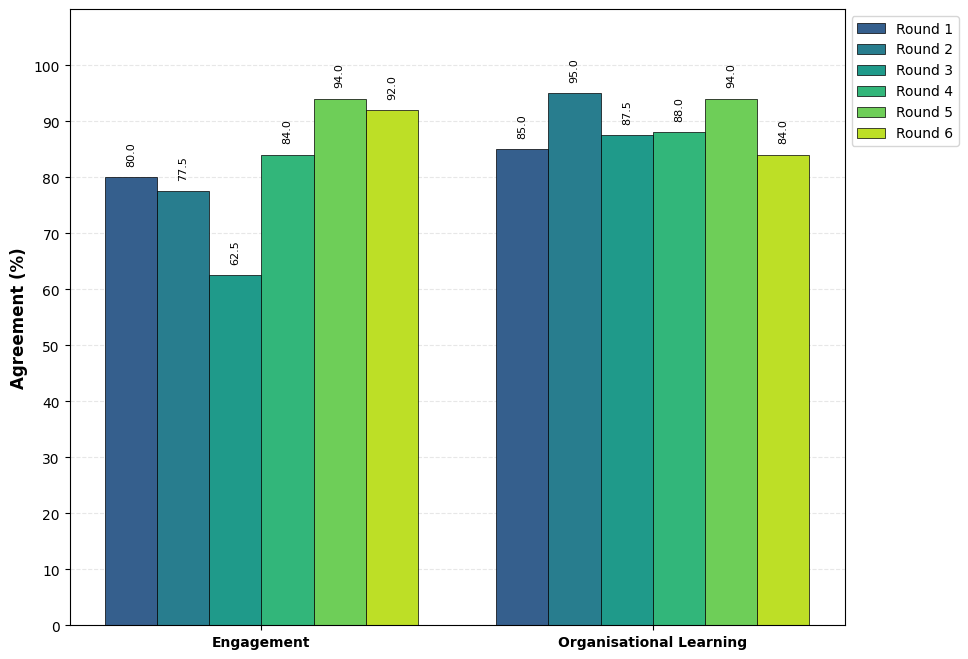

In [7]:
df_agreement = pd.concat([binary_irr[['Round','Variable','Agreement_pct']],ordinal_irr[['Round','Variable','Agreement_pct']]])
df_agreement = df_agreement.fillna(0)

fig, ax = plot_agreement_by_round(
    df_agreement, 
    y_col='Agreement_pct',
    
    variable_order=['engagement', 'organisationalLearning'],
    variable_labels={
        'engagement': 'Engagement',
        'organisationalLearning': 'Organisational Learning',
    },
    figsize = (10, 8), 
    show_ci=False,
    title=None,
    ylabel="Agreement (%)",
    xlabel = 0
    
)
plt.show()

The agreement plot shows a broadly positive trajectory for both engagement and organisationalLearning across the six rounds. Engagement maintained consistently high agreement throughout, with a visible dip in Round 3 that recovered fully by Round 4. Agreement for organisationalLearning showed greater variability — consistent with its lower and more variable Krippendorff α values — but trended upward across the later rounds.

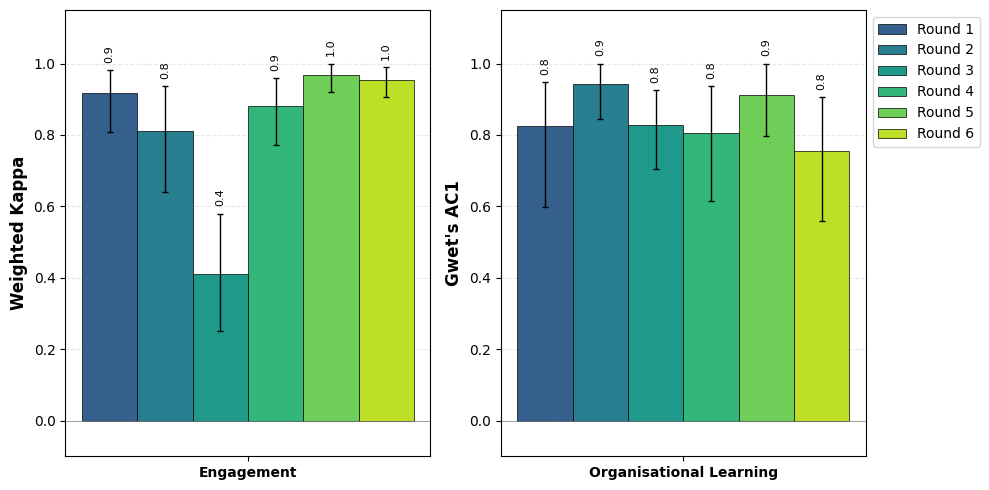

In [8]:
plot_configs = [
    {
        'df': ordinal_irr, 
        'y_col': 'Weighted_kappa',
        'show_ci': True,
        'ci_lower_col': 'Kappa_CI_lower',
        'ci_upper_col': 'Kappa_CI_upper',
        'title': "",
        'variable_labels': {
            'engagement': 'Engagement',
        },
        'ylabel': 'Weighted Kappa',
        'xlabel':None
    },
    {
        'df': binary_irr.fillna(0), 
        'y_col': 'Gwet_AC1', 
        'title': '',
        'ylabel': "Gwet's AC1",
        'show_ci': True,
        'ci_lower_col': 'Gwet_CI_lower',
        'ci_upper_col': 'Gwet_CI_upper',
        'variable_order': ['organisationalLearning'],
        'variable_labels': {
            'organisationalLearning': 'Organisational Learning'
        },
        'xlabel': None
    },

]

fig, axes = create_subplot_figure(
    plot_configs, 
    nrows=1, 
    ncols=2, 
    figsize=(10, 5),
    share_legend=True,  # Shows one legend on the rightmost plot
    suptitle=""
)
plt.show()

The IRR plots show weighted kappa (engagement) and Gwet's AC1 (organisational learning) across pilot rounds, with 95% bootstrap confidence intervals. Confidence intervals are wider in the earlier rounds where coding batch sizes were smaller, and narrow as sample sizes increase. By Rounds 5 and 6, reliability estimates for both variables carry comparatively tight confidence intervals, reflecting stable and consistent coding. Weighted kappa for engagement reached excellent levels (≥ 0.80) from Round 1 and was maintained throughout, while Gwet's AC1 for organisational learning showed greater variability, but had a generally upward trend.

Print the disagreements across all variables:

In [9]:

# Create name dictionary for cleaner output
rename_vars = {
    'isComplaint':"Is a complaint",
    'engagement': 'Engagement',
    'organisationalLearning':"Organisational Learning"}

# Specify variable types
var_types = {
    'isComplaint':"nominal",
    'organisationalLearning':"nominal",
    'engagement': 'ordinal',
}

# Get summary by round
summary_by_round = get_disagreements_summary(
    PilotRounds, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_round=True
)

# Get overall summary (across all rounds)
overall_summary = get_disagreements_summary(
    PilotRounds, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_round=False
)

# Display the results
summary_by_round

,Round,Variable,Variable_Type,N_Coded,N_Disagreements,Pct_Disagreements
0,Round_1,Is a complaint,nominal,20,0,0.0
1,Round_1,Engagement,ordinal,20,4,20.0
2,Round_1,Organisational Learning,nominal,20,3,15.0
3,Round_2,Is a complaint,nominal,40,0,0.0
4,Round_2,Engagement,ordinal,40,9,22.5
5,Round_2,Organisational Learning,nominal,40,2,5.0
6,Round_3,Is a complaint,nominal,80,0,0.0
7,Round_3,Engagement,ordinal,80,30,37.5
8,Round_3,Organisational Learning,nominal,80,10,12.5
9,Round_4,Is a complaint,nominal,50,1,2.0


(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Percentage of Disagreements Across Variables by Round'}, xlabel='Round', ylabel='Percentage of Disagreements (%)'>)

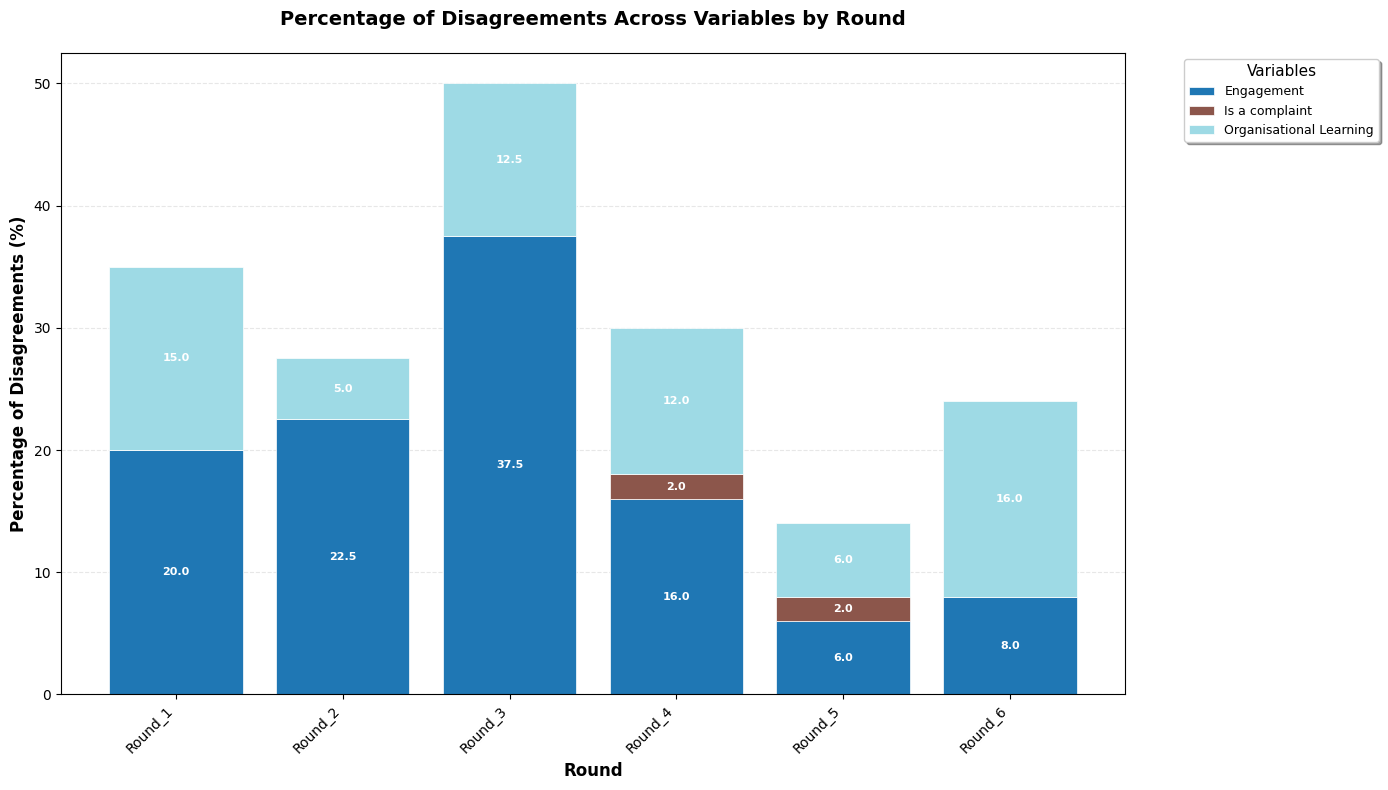

In [10]:
plot_disagreement_stacked_bar(summary_by_round)

The chart shows that is a complaint had consistently low disagreement rates across all rounds. Engagement and organisational learning generated more frequent disagreements, particularly in the earlier rounds, reducing substantially from Round 4 onwards.

## 1.2 Inter-rater reliability

Below shows the results of the final round of coding (Round 7) where coders were provided 400 story-response pairs each, of which 200 were shared amongst them and 200 were unique to the coder. The inter-rater reliability was calculated on the shared 200 and the two coders were not made aware of which story-response pairs were shared to mitigate any biases.

In [11]:

for var in bin_vars:
    c1 = FinalRound_IRR[f"{var}_C1"]
    c2 = FinalRound_IRR[f"{var}_C2"]

    # Calculate Krippendorff's alpha with CI
    alpha_result = bootstrap_ci_krippendorff(c1, c2, n_bootstrap=1000, random_state=42)
    
    # Calculate Gwet's AC1 with CI
    ac1_result = bootstrap_ci_gwet_ac1(c1, c2, n_bootstrap=1000, random_state=42)
    
    # Calculate percent agreement
    agreement = percent_agreement(c1, c2)
    
    # Get display name
    display_name = rename_vars.get(var, var)

    print(
        f"{display_name}:\n"
        f"  Krippendorff's α = {alpha_result['alpha']:.3f} "
        f"[95% CI: {alpha_result['CI_lower']:.3f}, {alpha_result['CI_upper']:.3f}]\n"
        f"  Gwet's AC1 = {ac1_result['AC1']:.3f} "
        f"[95% CI: {ac1_result['CI_lower']:.3f}, {ac1_result['CI_upper']:.3f}]\n"
        f"  Agreement = {agreement}%\n"
    )


Is a complaint:
  Krippendorff's α = 0.990 [95% CI: 0.969, 1.000]
  Gwet's AC1 = 0.990 [95% CI: 0.970, 1.000]
  Agreement = 99.5%

Organisational Learning:
  Krippendorff's α = 0.598 [95% CI: 0.423, 0.740]
  Gwet's AC1 = 0.839 [95% CI: 0.767, 0.903]
  Agreement = 88.5%



Reliability for is a complaint in the final coding round was excellent (α = 0.990). For organisational learning, Reliability was acceptable (α = 0.598; AC1 = 0.839), the discrepancy between α and Gwet's AC1 reflects the low base rate of organisational learning responses in the coding sample.

In [12]:

ordinal_vars = ['engagement']

ordinal_ranges = {
    'engagement': [0, 1, 2],  
}

for var in ordinal_vars:
    c1 = FinalRound_IRR[f"{var}_C1"]
    c2 = FinalRound_IRR[f"{var}_C2"]
    
    # Calculate ICC
    res = icc_3k_ordinal(FinalRound_IRR, var)
    
    # Get labels for this variable (if defined in ordinal_ranges)
    var_labels = ordinal_ranges.get(var, None)
    
    # Calculate Weighted Kappa with CI (using quadratic weights for ordinal data)
    kappa_result = bootstrap_ci_weighted_kappa(
        c1, c2,
        weights='quadratic',  # Use quadratic weights for ordinal data
        n_bootstrap=1000,
        confidence=0.95,
        random_state=42,
        labels=var_labels  # Pass the full range if available
    )
    
    # Calculate percent agreement
    agreement = percent_agreement(c1, c2)
    
    # Get display name
    display_name = rename_vars.get(var, var)

    print(
        f"{display_name}:\n"
        f"  ICC(3,k) = {res['ICC3k']:.3f} "
        f"[95% CI: {res['CI95%'][0]:.3f}, {res['CI95%'][1]:.3f}], "
        f"p = {res['pval']:.3g}\n"
        f"  Weighted Kappa (quadratic) = {kappa_result['kappa']:.3f} "
        f"[95% CI: {kappa_result['CI_lower']:.3f}, {kappa_result['CI_upper']:.3f}]\n"
        f"  Agreement = {agreement:.1f}%\n"
    )

Engagement:
  ICC(3,k) = 0.949 [95% CI: 0.930, 0.960], p = 3.65e-75
  Weighted Kappa (quadratic) = 0.900 [95% CI: 0.859, 0.933]
  Agreement = 86.0%



Reliability for engagement in the final coding round was excellent (ICC(3,k) = 0.949; κ = 0.900).

In [13]:
overall_summary = get_disagreements_summary(
    FinalRound_IRR, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_round=False
)

In [14]:
overall_summary

,Variable,Variable_Type,N_Coded,N_Disagreements,Pct_Disagreements
0,Is a complaint,nominal,200,1,0.5
1,Engagement,ordinal,200,28,14.0
2,Organisational Learning,nominal,200,23,11.5


In the final coding round, is a complaint had the lowest disagreement rate (0.5%; 1 of 200 cases), while engagement (14.0%; 28/200) and organisational learning (11.5%; 23/200) generated more disagreements. The higher rates for the latter two variables are consistent with the more complex conceptualisations of the variables.

# 2. Classifier development

The gold-standard dataset created through manual coding was subsequently used to develop a text classifier for engagement and organisational learning. Below is the variable mapping (expressed as Pydantic models) and three corresponding prompts used with GPT models. These are the final prompts created after a process of iterative development. Note that engagement was reduced to a binary variable during the development of the prompt. The full dataset was coded using these prompts on GPT-5-mini (Low Reasoning). Instructions for passing to the OpenAI API are provided below for demonstration purposes and replication. 

In [38]:
# Prompt 1 model - identifies if complaint, sent to all stories without responses
class Prompt1Model(BaseModel):
    # Is a complaint
    isComplaint: int = Field(description="Is this a complaint? 0 for No, 1 for Yes")
    isComplaintReasoning: str = Field(description="Reason for complaint classification.")
    isComplaintQuote: str = Field(description="Indicative quote for complaint classification.")
    
# Prompt 2 model - identifies engagement and organisational learning. All complaints identified from Prompt 1 sent with responses included.
class Prompt2Model(BaseModel):
    # To what degree does the response engage with the complaint
    engagementResponse: int = Field(description="Does the response engage with the issues in the complaint? 0 for No, 1 for Yes")
    engagementResponseReasoning: str = Field(description="Reason for engagement response classification.")
    engagementResponseQuote: str = Field(description="Indicative quote for engagement response  classification.")
    # Does the response provide evidence of organisational learning
    organisationalLearningResponse: int = Field(description="Does the response provide evidence of organisational learning? 0 for No, 1 for Yes")
    organisationalLearningResponseReasoning: str = Field(description="Reason for organisational learning in response classification.")
    organisationalLearningResponseQuote: str = Field(description="Indicative quote for organisational learning in response classification.")


In [39]:

# SYSTEM PROMPT FOR THE 1ST PROMPT
System1 = """You are an organisational psychologist tasked with analysing stories written about a UK healthcare providers.
General terminology:
Healthcare provider = The organisation who the story is directed towards
Storyteller = The person relaying the story (e.g., patient, loved one, friend)
Story = The story about a healthcare provider
Complaint = A story that provides negative feedback about the healthcare provider"""


# PROMPT 1 FOR IDENTIFYING IF A COMPLAINT
Prompt1 = """Below is a story written by a person about their experiences with a healthcare provider.
Your task is to identify whether the story is a complaint by indicating whether the story reports ANY patient harm caused by an error, failure, or violation by the healthcare provider.
The harm must have been caused by a health service mishap or actions taken by healthcare workers.

-
STORY:
{story_text}
-

Please answer the following questions:

First, is this story a complaint?
Scoring scheme: 
[0] - "No"
[1] - "Yes"

If relevant, please include a short (one sentence) quote from the raw text that supports your rating.
Please justify your ratings for each question in ONE SENTENCE."""


# SYSTEM PROMPT FOR THE 1ST AND 2ND PROMPT
System2 = """You are an organisational psychologist tasked with analysing complaints written about a UK healthcare providers.
General terminology:
Healthcare provider = The organisation who the story is directed towards
Storyteller = The person relaying the story (e.g., patient, loved one, friend)
Responder = The person replying to the story (e.g., complaints handler)
Story = The story about a healthcare provider
Complaint = A story that provides negative feedback about the healthcare provider
Issue = Problems raised within a complaint caused by a health service mishap or actions taken by healthcare workers
Response = The healthcare provider's response to the story"""

# PROMPT 2 FOR IDENTIFYING RESPONSE VARIABLES
Prompt2 = """Below is a complaint about a healthcare provider and the provider's response to the complaint.
Your task is to assess the quality and degree of engagement in the response.

-
COMPLAINT:
{complaint_text}
RESPONSE:
{response_text}
-

Please answer the following questions:

First, does the response engage with the issues raised in the complaint?
Scoring scheme:
[0] "No" - Response provides a rudimentary or brief paraphrasing of one or more issues and does not mention any of the issues raised, or is a generic / group response.
[1] "Yes" – Response demonstrates beyond rudimentary engagement with one or more issues.

Second, does the response report any evidence of organisational learning?
Scoring scheme:
[0] "No learning" – Does not report any current or future measures to prevent issue(s) occurring in future.
[1] "Learning evidenced" - Reports current or future measures to prevent issue(s) occurring in future.

If relevant, please include a short (one sentence) quote from the raw text that supports each of your ratings.
Please justify your ratings for each question in ONE SENTENCE."""

In [44]:
class classifier:
    def __init__(self, client, model="gpt-5-mini", reasoning_effort="low"):
        self.client = client
        self.model = model
        self.reasoning_effort = reasoning_effort

    def general_classifier(self, messages, response_model):
        response = self.client.beta.chat.completions.parse(
                        model=self.model,
                        messages=messages,
                        reasoning_effort=self.reasoning_effort,
                        response_format=response_model
                    )
        return response.choices[0].message.parsed

    def Prompt1_classify(self, story_text):
        messages = [
                {"role": "system", "content": System1},
                {"role": "user", "content": Prompt1.format(story_text = story_text)}
            ]
        response = self. general_classifier(messages, Prompt1Model)
        return response


    def Prompt2_classify(self, complaint_text, response_text):
        messages = [
                {"role": "system", "content": System2},
                {"role": "user", "content": Prompt2.format(complaint_text = complaint_text, response_text = response_text)}
            ]
        response = self. general_classifier(messages, Prompt2Model)
        return response
    
    def demonstration_classifier(self, complaint_text, response_text):
        response1 = self.Prompt1_classify(complaint_text)
        response1 = response1.model_dump()
        response3 = self.Prompt2_classify(complaint_text, response_text)
        response3 = response3.model_dump()
        
        return f"""-- PROMPT 1 RESPONSES: --
        
Q1: Is this story a complaint?
Response: {response1["isComplaint"]}
Reasoning: {response1["isComplaintReasoning"]}
Supporting quote: {response1["isComplaintQuote"]}

-- PROMPT 2 RESPONSES: -- 

Q2: Does the response engage with the issues raised in the complaint? (1=Yes)
Response: {response3["engagementResponse"]}
Reasoning: {response3["engagementResponseReasoning"]}
Supporting quote: {response3["engagementResponseQuote"]}

Q3: Does the response report any evidence of organisational learning? (1=Yes)
Response: {response3["organisationalLearningResponse"]}
Reasoning: {response3["organisationalLearningResponseReasoning"]}
Supporting quote: {response3["organisationalLearningResponseQuote"]}
"""

The classifier can be used on any story-response pair to gain a classification. Below is an example from the dataset (https://www.careopinion.org.uk/169864) for demonstration purposes. An OpenAI API key is required to use the classifier. 

In [41]:
# Link to original story
example_story = """My husband was admitted as an emergency from A&E and then taken to the Adult critical care unit where he died.
The circumstances are questionable and the behaviour of some of the senior medical staff was disgraceful, never want to set foot in this hospital again"""

example_response = """We are extremely sorry that you have been left so distressed following your husband's sad death at our hospital. 
We are also very sorry for the significant delay in responding to your posting on the NHS Choices website. 
It is difficult to respond to your concerns fully due to the anonymity of the the website. 
We would be more than happy to meet with you to discuss any concerns you may have and offer support. 
If you contact our Patient Advice and Liaison Service (PALS) on 0161 276 8686 or by emailing pals@cmft.nhs.uk they will be able to arrange this for you.
The Patient Experience Team
Central Manchester University Hospitals, NHS Foundation Trust
"""

In [46]:
OIAK = "-your-OpenAI-API-key-here"

client = OpenAI(
    api_key=OIAK,
)

In [45]:
gptClassifier = classifier(client = client)
example_output = gptClassifier.demonstration_classifier(complaint_text = example_story, response_text = example_response)
print(example_output)

-- PROMPT 1 RESPONSES: --

Q1: Is this story a complaint?
Response: 1
Reasoning: The story reports the patient's death following admission and criticises the conduct of senior medical staff, implying harm related to the healthcare provider's actions or failures.
Supporting quote: "The circumstances are questionable and the behaviour of some of the senior medical staff was disgraceful"

-- PROMPT 2 RESPONSES: -- 

Q2: Does the response engage with the issues raised in the complaint? (1=Yes)
Response: 1
Reasoning: The response acknowledges the bereavement and the concerns, apologises for the delay, and offers a specific route (PALS) and meeting to discuss the issues, showing active engagement beyond a generic statement.
Supporting quote: We would be more than happy to meet with you to discuss any concerns you may have and offer support.

Q3: Does the response report any evidence of organisational learning? (1=Yes)
Response: 0
Reasoning: The response contains no statement of investigation

## 2.1 Training and prompt development

Below details the results of the prompt adjustments for fine-tuning the LLM classifier to the manually coded data. We used a 30/70 train-test split of the data, meaning that 70% of the data was witheld from prompt development and only used to assess the final prompt.

In [16]:
train_results = pd.read_csv("final_data/train_results.csv")
test_results = pd.read_csv("final_data/test_results.csv")

train_size = len(train_results)
test_size = len(test_results)
total_size = train_size + test_size
train_pct = 100*(train_size / total_size)
test_pct = 100*(test_size / total_size)

print(f"""
Total number of story-response pairs = {total_size}
Train size = {train_size}({train_pct:.2f}%)
Test size = {test_size}({test_pct:.2f}%)
""")


Total number of story-response pairs = 600
Train size = 180(30.00%)
Test size = 420(70.00%)



The prompt development happened over eight iterations of adjustments. This involved running the prompt over the training data, examining the evaluation metrics and misclassifications, and adjusting the prompts accordingly. After the fourth iteration, we noted that the classifier was good at identifying the presence of engagement, but not good at distinguishing between different levels of the variable. We therefore adjusted the prompt to identify engagement as a binary variable, requiring us to create binary variables from the originally manually coded data:

In [18]:
train_results["engagement_trueBin"] = train_results.engagement_true.apply(lambda x: 1 if x > 1 else 0)

In [19]:


def camel_case_split(text):
    """Split camelCase text into separate words"""
    return re.sub('([a-z])([A-Z])', r'\1 \2', text)

train_complaints = train_results[train_results.isComplaint_true == 1].copy()

# Define binary classifier configurations
binary_configs = [
    ('isComplaint', train_results, 3),
    ('organisationalLearning', train_complaints, 8),
]

# Define special binary cases
special_binary = [
    ('engagement', train_complaints, 'trueBin', [4,5,6,7,8]),
]

# Define ordinal classifier configurations
ordinal_configs = [
    ('engagement', train_complaints, 3),
]

# Generate binary results
binary_results = []
for field, data, iterations in binary_configs:
    # Split camelCase and clean up
    name = camel_case_split(field)
    name = name.replace('', '').replace('Request', ' Request').replace('Learning', ' Learning')
    name = ' '.join(word.capitalize() for word in name.split())
    
    # Handle special cases
    if field == "organisationalLearning":
        name = "Organisational Learning"
        
    for i in range(1, iterations + 1):
        binary_results.append(
            evaluate_binary_classifier(
                data[f'{field}_true'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

# Add special binary cases
for field, data, suffix, iterations in special_binary:
    name = ' '.join(word.capitalize() for word in field.split())
    
    for i in iterations:
        binary_results.append(
            evaluate_binary_classifier(
                data[f'{field}_{suffix}'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

# Generate ordinal results
ord_results = []
for field, data, iterations in ordinal_configs:
    name = ' '.join(word.capitalize() for word in name.split())
    
    for i in range(1, iterations + 1):
        ord_results.append(
            evaluate_ordinal_classifier(
                data[f'{field}_true'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

train_bin_results = pd.DataFrame(binary_results).round(2)
train_ord_results = pd.DataFrame(ord_results).round(2)

We can observe below from the results of the prompt iterations how the accuracy jumps from 0.67 to 0.84 for engagement response after switching to a binary classification and from 0.67 to 0.73 for intervention response. This justifies our changes to the prompt. 

Binary results across iterations:

In [20]:
train_bin_results

,name,iteration,n,accuracy,precision,recall,f1,mcc,tp,tn,fp,fn
0,Is Complaint,1,180,0.94,1.00,0.88,0.94,0.89,72,98,0,10
1,Is Complaint,2,180,0.93,1.00,0.85,0.92,0.87,70,98,0,12
2,Is Complaint,3,180,0.94,1.00,0.87,0.93,0.88,71,98,0,11
3,Organisational Learning,1,82,0.79,0.74,0.61,0.67,0.52,17,48,6,11
4,Organisational Learning,2,82,0.80,0.77,0.61,0.68,0.55,17,49,5,11
5,Organisational Learning,3,82,0.83,0.85,0.61,0.71,0.61,17,51,3,11
6,Organisational Learning,4,82,0.82,0.88,0.54,0.67,0.58,15,52,2,13
7,Organisational Learning,5,82,0.80,0.88,0.50,0.64,0.55,14,52,2,14
8,Organisational Learning,6,82,0.80,0.75,0.64,0.69,0.55,18,48,6,10
9,Organisational Learning,7,82,0.84,0.74,0.82,0.78,0.66,23,46,8,5


Ordinal results across iterations:

In [21]:
train_ord_results

,name,iteration,n,classes,accuracy,mae,within_1_acc,kappa_linear,spearman_r,spearman_p,kendall_tau,kendall_p
0,Engagement,1,82,"[0, 1, 2]",0.50,0.51,0.99,0.42,0.64,0.0,0.60,0.0
1,Engagement,2,82,"[0, 1, 2]",0.65,0.37,0.99,0.58,0.70,0.0,0.65,0.0
2,Engagement,3,82,"[0, 1, 2]",0.56,0.46,0.98,0.50,0.73,0.0,0.68,0.0


Plot of the accuracy for engagement and organisational learning for all rounds.

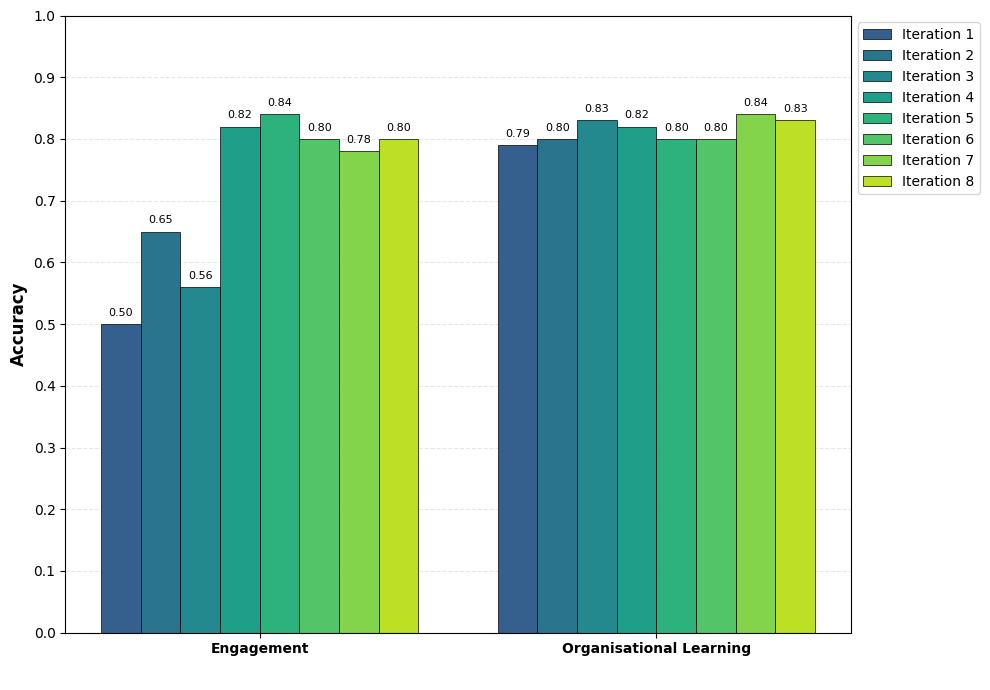

In [22]:

# Create shared dataframe from results
train_bin_acc = train_bin_results[["name", "iteration", "accuracy"]].reset_index().copy()
train_ord_acc = train_ord_results[["name", "iteration", "accuracy"]].reset_index().copy()
train_accuracy = pd.concat([train_bin_acc, train_ord_acc])
# Variable ordering
name_order = ['Engagement', 'Organisational Learning']
# Plot the results
fig, ax = plot_grouped_accuracy(train_accuracy, figsize=(10, 7), 
                                name_order = name_order, 
                                show_values=True)
plt.show()


Plot the F1 score for the final five rounds after engagement switched to binary variable:

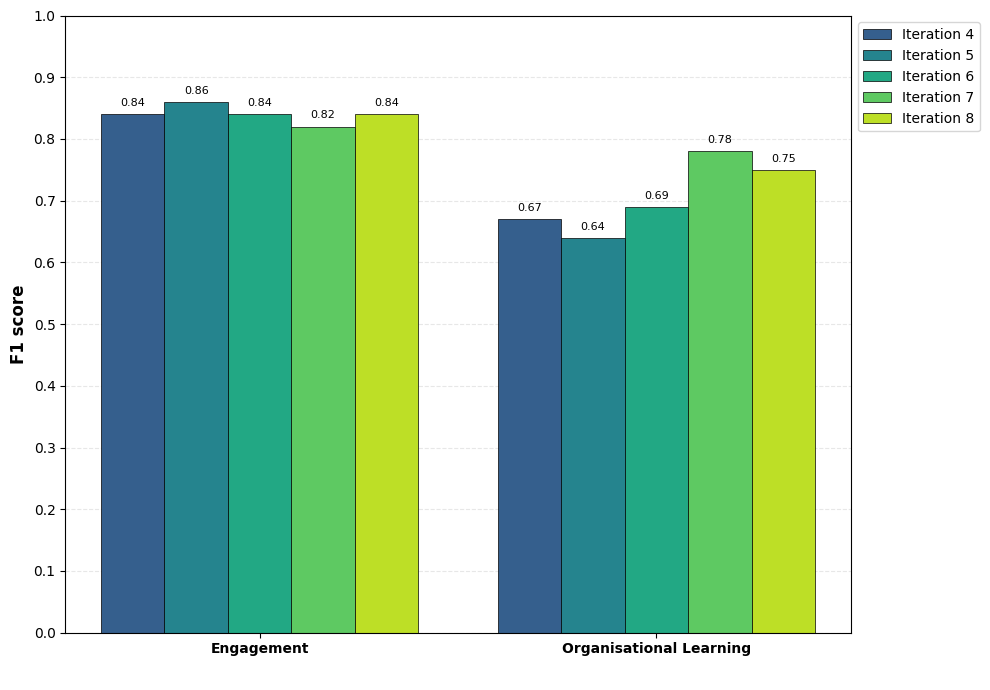

In [23]:
# Create shared dataframe from results\
train_bin_acc2 = train_bin_results[["name", "iteration", "f1"]].reset_index().copy()
train_bin_acc2 = train_bin_acc2[train_bin_acc2['iteration'] > 3]
# Variable ordering
name_order = [ 'Engagement', 'Organisational Learning']
# Plot the results
fig, ax = plot_grouped_accuracy(train_bin_acc2, figsize=(10, 7), 
                                name_order = name_order, 
                                show_values=True, metric ='f1', ylabel ='F1 score')
plt.show()

## 2.2 Validation

We used the prompt from the 7th iteration to assess the classifier on the test data. The prompts were not developed on the test data and therefore we can be assured of an unbiased evaluation. We employed the prompts on three models to determine which would be best for coding the full dataset: GPT-5-mini (low reasoning), GPT-5-mini (high reasoning), GPT-5 (high reasoning).

In [24]:
test_results = pd.read_csv("final_data/test_results.csv")

In [25]:
test_complaints = test_results[test_results.isComplaint_true == 1]
# Define model versions
model_versions = [
    ('miniLow', 'GPT-5-mini (low)'),
    ('miniHigh', 'GPT-5-mini (high)'),
    ('5High', 'GPT-5 (high)')
]

# Define binary classifier configurations
binary_configs = [
    ('isComplaint', test_results, 'Is Complaint'),
    ('engagement', test_complaints, 'Engagement'),
    ('organisationalLearning', test_complaints, 'Organisational Learning'),
]

# Generate binary results
binary_results_test = []
for field, data, name in binary_configs:
    for version_suffix, version_name in model_versions:
        binary_results_test.append(
            evaluate_binary_classifier(
                data[f'{field}_true'],
                data[f'gpt_{field}_{version_suffix}'],
                name=name,
                iteration=version_name
            )
        )


test_bin_results = pd.DataFrame(binary_results_test).round(2)

In [26]:
test_bin_results

,name,iteration,n,accuracy,precision,recall,f1,mcc,tp,tn,fp,fn
0,Is Complaint,GPT-5-mini (low),420,0.94,0.98,0.89,0.93,0.88,171,224,3,22
1,Is Complaint,GPT-5-mini (high),420,0.94,0.99,0.87,0.93,0.88,168,226,1,25
2,Is Complaint,GPT-5 (high),420,0.96,0.99,0.92,0.95,0.92,178,225,2,15
3,Engagement,GPT-5-mini (low),193,0.82,0.78,0.97,0.86,0.64,111,47,32,3
4,Engagement,GPT-5-mini (high),193,0.82,0.78,0.97,0.86,0.64,111,47,32,3
5,Engagement,GPT-5 (high),193,0.89,0.93,0.88,0.90,0.78,100,72,7,14
6,Organisational Learning,GPT-5-mini (low),193,0.81,0.74,0.66,0.70,0.56,43,113,15,22
7,Organisational Learning,GPT-5-mini (high),193,0.80,0.75,0.62,0.68,0.54,40,115,13,25
8,Organisational Learning,GPT-5 (high),193,0.79,0.86,0.46,0.60,0.52,30,123,5,35


On the held-out test set, accuracy for is a complaint was high and consistent across model versions (GPT-5-mini low reasoning: 0.94; GPT-5-mini high reasoning: 0.94; GPT-5 high reasoning: 0.96). For engagement, GPT-5 (high reasoning) outperformed the mini variants (accuracy: 0.89 vs. 0.82) and achieved the best F1 score (0.90). For organisational learning, all models performed similarly (accuracy = 0.81), with GPT-5-mini (low reasoning) achieving the highest F1 (0.70).

Print the best model for our variables:

In [28]:
for name, group in test_bin_results.groupby('name'):
    best_row = group.loc[group['f1'].idxmax()]
    print(f"Variable: {name}")
    print(f"  Best Model: {best_row['iteration']}")
    print(f"  F1 Score: {best_row['f1']}")
    print()


Variable: Engagement
  Best Model: GPT-5 (high)
  F1 Score: 0.9

Variable: Is Complaint
  Best Model: GPT-5 (high)
  F1 Score: 0.95

Variable: Organisational Learning
  Best Model: GPT-5-mini (low)
  F1 Score: 0.7



Below performs a significance test to compare the classifiers to determine whether one is better to use than an other. We use a Friedman's test to assess if there is any difference between the three classifiers and post-hoc wilcoxon tests to test pairwise differences.

In [29]:
results = compare_classifiers_mixed_variables(
    df=test_results.drop(["story_id","title_text","story_text","response_text"], axis=1),
    classifier_names=['miniLow', 'miniHigh', '5High'],
    var_config='auto',
    metric='accuracy'
)


Mean accuracy across all variables:
classifier
5High       0.8812
miniLow     0.8558
miniHigh    0.8533
dtype: float64

=== Friedman Test (across all 3 variables) ===
Chi-squared statistic: 1.2727
p-value: 0.5292
Result: No significant difference found among classifiers (p >= 0.05)

=== Pairwise Comparisons (Wilcoxon signed-rank test) ===

miniLow vs miniHigh:
  Mean difference: 0.0025
  p-value: 0.5000
  Result: No significant difference

miniLow vs 5High:
  Mean difference: -0.0253
  p-value: 0.5000
  Result: No significant difference

miniHigh vs 5High:
  Mean difference: -0.0279
  p-value: 0.5000
  Result: No significant difference

=== With Bonferroni Correction (α = 0.0167) ===


Perform the test again but using the F1 scores:

In [30]:
results = compare_classifiers_mixed_variables(
    df=test_results.drop(["story_id","title_text","story_text","response_text"], axis=1),
    classifier_names=['miniLow', 'miniHigh', '5High'],
    var_config='auto',
    metric='f1'
)


Mean f1 across all variables:
classifier
miniLow     0.8316
miniHigh    0.8233
5High       0.8198
dtype: float64

=== Friedman Test (across all 3 variables) ===
Chi-squared statistic: 1.2727
p-value: 0.5292
Result: No significant difference found among classifiers (p >= 0.05)

=== Pairwise Comparisons (Wilcoxon signed-rank test) ===

miniLow vs miniHigh:
  Mean difference: 0.0083
  p-value: 0.5000
  Result: No significant difference

miniLow vs 5High:
  Mean difference: 0.0118
  p-value: 1.0000
  Result: No significant difference

miniHigh vs 5High:
  Mean difference: 0.0035
  p-value: 1.0000
  Result: No significant difference

=== With Bonferroni Correction (α = 0.0167) ===


The Friedman test found no significant difference in classification accuracy across the three model versions (χ² = 1.27, p = .529). Pairwise Wilcoxon signed-rank tests confirmed no significant pairwise differences (all p ≥ .50). When repeated using F1 scores, the same result was obtained (χ² = 1.27, p = .529), with mean F1 score marginally favouring GPT-5-mini (low reasoning: 0.832). Given the absence of any statistically significant performance difference, we selected GPT-5-mini with low reasoning for coding the full dataset, as it is the most cost-efficient option without sacrificing classification performance.

## 2.3 Misclassifications

In [ ]:
print_classification_examples(test_results, "engagement", # Change to variable of choice: isComplaint, engagement, organisationalLearning
                              ['title_text','story_text'], "FP")

Example 1 (Index: 221)
  True Label: 0 | Predicted Label: 1.0

title_text
  I didn't receive a follow up appointment

story_text
  In mid September I had a procedure at Chesterfield Royal Hospital under the Gynecology Dept. quite a run of the mill hernia. In hospital I was looked after & plenty of info for the 2 days I was in & I was told I would get a 4 week follow up appointment. When I came out I had 4 weeks off work, no follow up appointment came, so I rang & an appointment was made the beginning of December.
Last week my stitches which had not dissolved started to stick in me & cause bleeding, I rang Gyne Dept & was told to get in touch with my GP, GP said they couldn't do anything about internal stitches, so where did that leave me, GP receptionist rang Gyne Dept. & was told by the same rude person that they must sort it out for me which they very kindly took the stitch out which was causing me the problem. I know it's only a minor complaint but if I had the 4 week appointment as

# 3. External validation

This section details descriptive statistics, correlation coefficients, and a mixed effects regression model exploring the relationship between engagement and organisational learning with the NHS England Staff Survey. 

In [27]:
df = pd.read_csv("final_data/full_dataset.csv")
ndf = len(df)
print(f"Number of Story-Response Pairs {ndf}")

Number of Story-Response Pairs 157051


In [28]:
df['org_idx'] = df['org_idx'].str.split('-').str[0].str.upper()
df['org_idx'] = df['org_idx'].str.split('_').str[0].str.upper()
print(f"Number of acute hospitals in dataset = {len(df.org_idx.unique())}")

Number of acute hospitals in dataset = 1074


From the full dataset, story-response pairs classified as complaints are extracted as a subset. All subsequent analyses of engagement and organisational learning are conducted on this subset, as these variables are only meaningful for feedback that constitutes a complaint.

In [30]:
complaint_df = df[df.isComplaint == 1].copy()
ncomp = len(complaint_df)
pctcomp = 100*(ncomp/ndf)
print(f"Number of complaints = {len(complaint_df)} ({pctcomp:.2f}%)")

Number of complaints = 53028 (33.76%)


The complaints data are aggregated to the trust-year level to create a dataframe suitable for longitudinal analysis. Each row represents a unique combination of NHS trust and year, with engagement and organisational learning expressed as proportions of complaints received in that period.

In [31]:
keep_first_vars = [
    'trust_name',
    'trust_region',
]

keep_first_vars2 = [
    'trust_shmi',
    'trust_spells',
]

mean_vars = [
    'story_wordCount',
    'resp_wordCount',
    'story_sentiment',
    'engagement',
    'organisationalLearning',
]

nunique_vars = [
    'resp_Author'
]

def first_non_na(s):
    """Return first non-NA value, or NA if all are NA"""
    valid = s.dropna()
    return valid.iloc[0] if len(valid) > 0 else pd.NA

def aggregation(df, group_cols):
    """Helper function for aggregation"""
    
    agg_dict = {}

    # Means
    for col in mean_vars:
        agg_dict[col] = 'mean'

    # Unique counts
    for col in nunique_vars:
        agg_dict[col] = 'nunique'

    # First non-NA
    for col in keep_first_vars + keep_first_vars2:
        agg_dict[col] = first_non_na

    # Main aggregation
    grouped = df.groupby(group_cols)
    out_df = grouped.agg(agg_dict)

    # Add row count per group
    out_df['nFeedback'] = grouped.size()

    return out_df.reset_index()

# 1. Trust × Year aggregation
group_cdf = aggregation(
    complaint_df,
    group_cols=['trust_idx', 'year']
)

# 2. Year-level aggregates
yeargroup = aggregation(
    complaint_df,
    group_cols=['year']
)

# 3. Trust-level aggregates
trustgroup = aggregation(
    complaint_df,
    group_cols=['trust_idx']
)


In [32]:
print(f"Number of data points Year x Trusts: {len(group_cdf)}")
print(f"Number of years in data: {len(yeargroup)}")
print(f"Number of trusts in data: {len(trustgroup)}")

Number of data points Year x Trusts: 1295
Number of years in data: 13
Number of trusts in data: 109


A second aggregated dataframe is created at the NHS organisation level (rather than trust level) to facilitate linkage with staff survey data, which is reported at the organisational rather than trust level.

In [33]:
keep_first_vars = [
    'trust_idx',
    'trust_region',
]

org_year_vars = [
    'ss_q19a_organisationTreatsStaffInvolvedInIncidentFairly_score',
    'ss_q19b_organisationEncouragesReportingIncidents_score',
    'ss_q19c_organisationTakesActionsFollowingIncidents_score',
    'ss_q19d_toldAboutChangesFollowingIncidents_score',
    'ss_q20a_feelSafeRaisingConcernsAboutUnsafePractice_score',
    'ss_q20b_confidenceInOrganisationAddressingConcerns_score',
    'ss_q25b_organisationActsOnPatientConcerns_score',
]

mean_vars = [
    'story_wordCount',
    'resp_wordCount',
    'story_sentiment',
    'engagement',
    'organisationalLearning',
]

nunique_vars = [
    'resp_Author'
]

def aggregation_ss(df, group_cols, agg_org_year_vars='first'):
    """Helper function for staff survey aggregation"""
    agg_dict = {}
    for col in mean_vars:
        agg_dict[col] = 'mean'
    for col in keep_first_vars:
        agg_dict[col] = first_non_na
        # Unique counts
    for col in nunique_vars:
        agg_dict[col] = 'nunique'
    # org_year_vars: 'first' at org-year level, 'mean' at higher levels
    for col in org_year_vars:
        agg_dict[col] = first_non_na if agg_org_year_vars == 'first' else 'mean'
    
    grouped = df.groupby(group_cols)
    out_df = grouped.agg(agg_dict)

    out_df['nFeedback'] = grouped.size()
    return out_df.reset_index()

# 1. Organisation × Year aggregation (from raw complaints)
group_cdf_ss = aggregation_ss(
    complaint_df,
    group_cols=['org_idx', 'year'],
    agg_org_year_vars='first'
)

# 2. Organisation-level aggregates (from org-year data)
orggroup_ss = aggregation_ss(
    df,
    group_cols=['org_idx'],
    agg_org_year_vars='mean'
)

In [34]:
print(f"Number of data points Year x Organisation: {len(group_cdf_ss)}")
print(f"Number of Organisation in data: {len(orggroup_ss)}")

Number of data points Year x Organisation: 4314
Number of Organisation in data: 1074


Log transformations are applied to word count variables prior to inclusion as control variables in regression models, to reduce the right-skew typical of word count distributions.

In [35]:
log_vars1 = ['story_wordCount', 'resp_wordCount', 'trust_spells']
log_vars2 = ['story_wordCount', 'resp_wordCount']

for var in log_vars1:
    min_val = group_cdf[var].min()
    offset = abs(min_val) + 1 if min_val <= 0 else 0
    group_cdf[f'{var}_log'] = np.log(group_cdf[var] + offset)

for var in log_vars2:
    min_val = group_cdf_ss[var].min()
    offset = abs(min_val) + 1 if min_val <= 0 else 0
    group_cdf_ss[f'{var}_log'] = np.log(group_cdf_ss[var] + offset)
    

for var in log_vars1:
    min_val = trustgroup[var].min()
    offset = abs(min_val) + 1 if min_val <= 0 else 0
    trustgroup[f'{var}_log'] = np.log(trustgroup[var] + offset)

for var in log_vars2:
    min_val = orggroup_ss[var].min()
    offset = abs(min_val) + 1 if min_val <= 0 else 0
    orggroup_ss[f'{var}_log'] = np.log(orggroup_ss[var] + offset)

group_cdf["year"] = group_cdf["year"].astype(float)
group_cdf_ss["year"] = group_cdf_ss["year"].astype(float)


## 3.1 Create Staff Survey Corrective Culture Measure

Seven items from the NHS staff survey were selected based on their relevance to corrective culture:

1. Q19a: My organisation treats staff who are involved in an error near miss or incident fairly
2. Q19b: My organisation encourages us to report errors near misses or incidents
3. Q19c: When errors, near misses, or incidents are reported, my organisation takes action to ensure that they do not happen again
4. Q19d: We are given feedback about changes made in response to reported errors near misses and incidents
5. Q20a: I would feel secure raising concerns about unsafe clinical practice
6. Q20b: I am confident that my organisation would address my concern
7. Q25b: My organisation acts on concerns raised by patients and organisation users


The first step is to create a single aggregated measure of corrective culture from the staff survey data. This involves (1) seeing if the survey items are internally reliable so they can be aggregated (2) removing any items that reduces the reliability:

In [36]:
staff_survey_Qs = ['ss_q19a_organisationTreatsStaffInvolvedInIncidentFairly_score',
                    'ss_q19b_organisationEncouragesReportingIncidents_score',
                    'ss_q19c_organisationTakesActionsFollowingIncidents_score',
                    'ss_q19d_toldAboutChangesFollowingIncidents_score',
                    'ss_q20a_feelSafeRaisingConcernsAboutUnsafePractice_score',
                    'ss_q20b_confidenceInOrganisationAddressingConcerns_score',
                    'ss_q25b_organisationActsOnPatientConcerns_score',
]

Using the seven corrective culture items we iterate across the alphas to determine which items we can keep without reducing the scale. We do this by removing an item and checking if the alpha increases. We do this for all item combinations, keeping the highest number of items.

In [37]:


staff_survey_Qs2 = ['ss_q19a_organisationTreatsStaffInvolvedInIncidentFairly_score',
                    'ss_q19b_organisationEncouragesReportingIncidents_score',
                    'ss_q19c_organisationTakesActionsFollowingIncidents_score',
                    'ss_q19d_toldAboutChangesFollowingIncidents_score',
                    'ss_q20a_feelSafeRaisingConcernsAboutUnsafePractice_score',
                    'ss_q20b_confidenceInOrganisationAddressingConcerns_score',
                    'ss_q25b_organisationActsOnPatientConcerns_score',
]

df_items = group_cdf_ss[staff_survey_Qs2]  # only the items
df_items = df_items.apply(pd.to_numeric, errors="coerce")


# Find all valid combinations
valid_combinations = []

# Test all combinations from size 3 to total number of items
for size in range(3, len(staff_survey_Qs2) + 1):
    for combo in combinations(staff_survey_Qs2, size):
        is_valid, alpha = check_all_deltas_negative(combo, df_items)
        if is_valid:
            valid_combinations.append({
                'items': combo,
                'n_items': len(combo),
                'alpha': alpha
            })

# Sort by number of items (descending) and then by alpha (descending)
valid_combinations.sort(key=lambda x: (x['n_items'], x['alpha']), reverse=True)

# Display results
if valid_combinations:
    print(f"Found {len(valid_combinations)} valid combination(s)\n")
    
    # Show the largest combination(s)
    max_size = valid_combinations[0]['n_items']
    largest_combos = [c for c in valid_combinations if c['n_items'] == max_size]
    
    print(f"Largest combination(s) with {max_size} items:\n")
    for i, combo in enumerate(largest_combos, 1):
        print(f"Combination {i}:")
        print(f"  Alpha: {combo['alpha']:.3f}")
        print(f"  Items:")
        for item in combo['items']:
            # Clean up item name for display
            item_short = item.replace('_score', '').split('_', 2)[-1]
            print(f"    - {item_short}")
        subset_df = df_items[list(combo['items'])]
        full_alpha = combo['alpha']
        
        for item in combo['items']:
            remaining_items = [i for i in combo['items'] if i != item]
            alpha_deleted, _ = pg.cronbach_alpha(data=df_items[remaining_items])
            delta_alpha = alpha_deleted - full_alpha
            item_short = item.replace('_score', '').split('_', 2)[-1]
            print(f"    Remove '{item_short}': Δα = {delta_alpha:.4f}")
        print()
else:
    print("No valid combinations found where all items are essential")

# Optional: Show summary statistics for all valid combinations
if len(valid_combinations) > 1:
    print("\nSummary of all valid combinations:")
    summary_df = pd.DataFrame([
        {'n_items': c['n_items'], 'alpha': c['alpha']} 
        for c in valid_combinations
    ])
    print(summary_df.groupby('n_items').agg({
        'alpha': ['count', 'min', 'max', 'mean']
    }).round(3))

Found 29 valid combination(s)

Largest combination(s) with 5 items:

Combination 1:
  Alpha: 0.930
  Items:
    - organisationTreatsStaffInvolvedInIncidentFairly
    - organisationTakesActionsFollowingIncidents
    - toldAboutChangesFollowingIncidents
    - feelSafeRaisingConcernsAboutUnsafePractice
    - confidenceInOrganisationAddressingConcerns
    Remove 'organisationTreatsStaffInvolvedInIncidentFairly': Δα = -0.0138
    Remove 'organisationTakesActionsFollowingIncidents': Δα = -0.0351
    Remove 'toldAboutChangesFollowingIncidents': Δα = -0.0017
    Remove 'feelSafeRaisingConcernsAboutUnsafePractice': Δα = -0.0040
    Remove 'confidenceInOrganisationAddressingConcerns': Δα = -0.0286

Combination 2:
  Alpha: 0.915
  Items:
    - organisationTreatsStaffInvolvedInIncidentFairly
    - organisationTakesActionsFollowingIncidents
    - toldAboutChangesFollowingIncidents
    - feelSafeRaisingConcernsAboutUnsafePractice
    - organisationActsOnPatientConcerns
    Remove 'organisationTreats

The iterations suggest that removing the second item leads to a set of items where removing any item would decrease the reliability, thereby suggesting a reliable scale. We can confirm this by calculating the suggested scale:

In [38]:
staff_survey_Qs2 = ['ss_q19a_organisationTreatsStaffInvolvedInIncidentFairly_score',
                    'ss_q19c_organisationTakesActionsFollowingIncidents_score',
                    'ss_q19d_toldAboutChangesFollowingIncidents_score',
                    'ss_q20a_feelSafeRaisingConcernsAboutUnsafePractice_score',
                    'ss_q20b_confidenceInOrganisationAddressingConcerns_score',
                    'ss_q25b_organisationActsOnPatientConcerns_score',
]
df_items = group_cdf_ss[staff_survey_Qs2]  # only the items
df_items = df_items.apply(pd.to_numeric, errors="coerce")

alpha = pg.cronbach_alpha(data=df_items)
print(f"Cronbach's α: {alpha[0]:.3f}")
results = []

full_alpha, _ = pg.cronbach_alpha(data=df_items)

for col in df_items.columns:
    alpha_deleted, _ = pg.cronbach_alpha(data=df_items.drop(columns=[col]))
    results.append({
        "item": col,
        "alpha_if_deleted": alpha_deleted,
        "delta_alpha": alpha_deleted - full_alpha
    })

alpha_deleted_df = pd.DataFrame(results).sort_values("alpha_if_deleted", ascending=False)
alpha_deleted_df.round(3)

Cronbach's α: 0.940


,item,alpha_if_deleted,delta_alpha
2,ss_q19d_toldAboutChangesFollowingIncidents_score,0.940,0.000
3,ss_q20a_feelSafeRaisingConcernsAboutUnsafePrac...,0.938,-0.002
0,ss_q19a_organisationTreatsStaffInvolvedInIncid...,0.932,-0.008
5,ss_q25b_organisationActsOnPatientConcerns_score,0.930,-0.010
4,ss_q20b_confidenceInOrganisationAddressingConc...,0.915,-0.025
1,ss_q19c_organisationTakesActionsFollowingIncid...,0.914,-0.026


The alpha-if-deleted values (range: 0.915–0.940) confirm that removing any retained item would not improve the scale, supporting the internal coherence of the scale.

Create a single staff survey measure based on the above scale:

In [39]:
print(f"Original dataframe length = {len(group_cdf_ss)}")
group_cdf_ss["staff_survey_score"] = group_cdf_ss[staff_survey_Qs2].mean(axis=1)
# remove any missing values
group_cdf_ss = group_cdf_ss.dropna(subset=["staff_survey_score"]).copy()
group_cdf_ss["staff_survey_score"] = group_cdf_ss["staff_survey_score"].astype(float)
print(f"New dataframe length = {len(group_cdf_ss)}")

Original dataframe length = 4314
New dataframe length = 3145


In [75]:
print(f"Number of unique hospitals = {len(group_cdf_ss.org_idx.unique())}")
print(f"Number of unique trusts = {len(group_cdf_ss.trust_idx.unique())}")

Number of unique hospitals = 763
Number of unique trusts = 104


## 3.2 Descriptive statistics

In [40]:
nEng = sum(complaint_df["engagement"])
pctEng = 100*(nEng/ncomp)
print(f"There are {nEng} ({pctEng:.2f}%) responses with evidence of engagement.")
nOL = sum(complaint_df["organisationalLearning"])
pctOL = 100*(nOL/ncomp)
print(f"There are {nOL} ({pctOL:.2f}%) responses with evidence of organisational learning.")


There are 28466.0 (53.68%) responses with evidence of engagement.
There are 9815.0 (18.51%) responses with evidence of organisational learning.


Of the 53,028 complaints in the dataset, 28,466 (53.68%) received a response demonstrating evidence of engagement and a smaller proportion received a response demonstrating organisational learning: 9,815 (18.51%).

### 3.2.1 Trust level descriptives

Pearson correlations between key variables at the trust-year level are shown below. Significance stars denote: \* p < .05, \*\* p < .01, \*\*\* p < .001.

In [89]:
corvars = ['year', 'story_wordCount', 'resp_wordCount', 'engagement', 'organisationalLearning']

corr_with_sig(group_cdf[corvars], method = 'spearman')

,year,story_wordCount,resp_wordCount,engagement,organisationalLearning
year,1.00,-0.50***,-0.04,-0.02,-0.17***
story_wordCount,-0.50***,1.00,0.13***,0.08**,0.17***
resp_wordCount,-0.04,0.13***,1.00,0.62***,0.47***
engagement,-0.02,0.08**,0.62***,1.00,0.68***
organisationalLearning,-0.17***,0.17***,0.47***,0.68***,1.00


At the trust-year level, response word count is strongly positively correlated with both engagement (r = 0.57, p < .001) and organisational learning (r = 0.49, p < .001), suggesting that more substantive organisational responses tend to demonstrate greater engagement and explicit learning content. Engagement and organisational learning are highly correlated with each other (r = 0.64, p < .001), consistent with both constructs capturing related but distinct aspects of response quality. Year shows a significant negative correlation with both organisational learning (r = −0.15, p < .001) and story word count (r = −0.37, p < .001). The correlation with story word count is odd and perhaps this is due to the covid years creating issues in the data. However, upon exploration, it makes no difference if we remove the covid years:

In [88]:
group_cdf_noCovid = group_cdf[group_cdf.year < 2019].copy()
corr_with_sig(group_cdf_noCovid[corvars], method = 'spearman')

,year,story_wordCount,resp_wordCount,engagement,organisationalLearning
year,1.00,-0.40***,-0.07*,0.01,-0.14***
story_wordCount,-0.40***,1.00,0.15***,0.08*,0.15***
resp_wordCount,-0.07*,0.15***,1.00,0.66***,0.49***
engagement,0.01,0.08*,0.66***,1.00,0.68***
organisationalLearning,-0.14***,0.15***,0.49***,0.68***,1.00


Histograms showing the distributions of engagement and organisational learning at the trust-year level, both before and after any transformations.

(<Figure size 800x600 with 4 Axes>,
 array([<Axes: xlabel='engagement', ylabel='Count'>,
        <Axes: xlabel='organisationalLearning', ylabel='Count'>,
        <Axes: xlabel='resp_wordCount', ylabel='Count'>,
        <Axes: xlabel='story_wordCount', ylabel='Count'>], dtype=object))

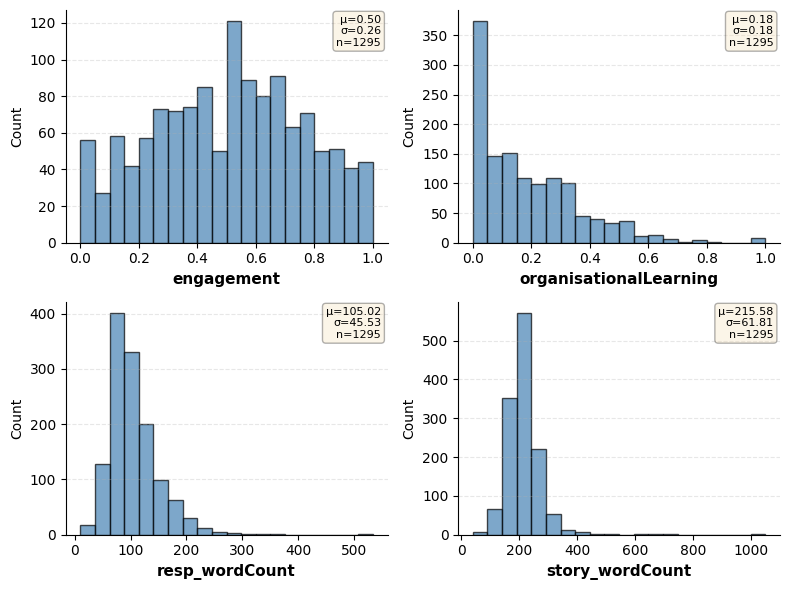

In [43]:
# Histogram of variables
histogram_grid(group_cdf,['engagement', 
                          'organisationalLearning', 
                          'resp_wordCount',
                          'story_wordCount',
                          ], ncols =2)


Descriptive statistics (mean, median, SD, min, max) for key variables at the trust-year level are shown below.

In [44]:

# Descriptive statistics
summary_stats(group_cdf, ['engagement', 'organisationalLearning',
                                   'resp_wordCount', 'story_wordCount']).round(2)

,Mean,Median,SD,Min,Max
engagement,0.50,0.50,0.26,0.0,1.0
organisationalLearning,0.18,0.14,0.18,0.0,1.0
resp_wordCount,105.02,96.23,45.53,10.0,534.0
story_wordCount,215.58,210.94,61.81,40.0,1050.0


At the trust-year level, mean engagement was 0.50 (SD = 0.26; range: 0.00–1.00), indicating that on average approximately half of complaints received a response demonstrating engagement. Mean organisational learning was substantially lower at 0.18 (SD = 0.18; range: 0.00–1.00). These reflect the proportion of engagement and organisational learning at the complaints level. The standard deviations indicate meaningful variability across trusts and years, with some trust-years showing engagement rates close to 0 or 1. Mean response word count was 105.0 words (SD = 45.5), and mean complaint word count was 215.6 words (SD = 61.8), indicating that responses were on average approximately half the length of the complaints they addressed — a difference confirmed as statistically significant below.

In [45]:
# At the level of complaints
summary_stats(complaint_df, ['resp_wordCount', 'story_wordCount']).round(2)

,Mean,Median,SD,Min,Max
resp_wordCount,106.82,89.0,66.72,2.0,1171.0
story_wordCount,212.13,168.0,165.01,4.0,3622.0


In [46]:
# Check that the wordcounts are significantly different from each other
group_cdf['wc_diff'] = group_cdf['resp_wordCount'] - group_cdf['story_wordCount']

print(f"Mean difference: {group_cdf['wc_diff'].mean():.1f} words")
print(f"Responses longer than complaints: {(group_cdf['wc_diff'] > 0).mean():.1%}")
stat, p_value = stats.wilcoxon(group_cdf['story_wordCount'], group_cdf['resp_wordCount'])

n = len(group_cdf['story_wordCount'])
z_score = (stat - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)

# Effect size (r = Z / sqrt(N))
r = abs(z_score) / np.sqrt(n)

print(f"W = {stat}, Z = {z_score:.2f}, p = {p_value:.3f}, r = {r:.2f}")

Mean difference: -110.6 words
Responses longer than complaints: 4.2%
W = 7718.5, Z = -30.60, p = 0.000, r = 0.85


Also of interest is that the majority of organisations only list one responding author and only receive one piece of feedback:

In [ ]:
group_cdf_ss.resp_Author.value_counts().head(5)

resp_Author
1    2121
2     647
3     228
4      66
0      14
Name: count, dtype: int64

In [48]:
group_cdf_ss.nFeedback.value_counts().head(5)

nFeedback
1    734
2    411
3    261
4    197
5    141
Name: count, dtype: int64

### 3.2.2 Organisation level descriptives

In [90]:
corvars2 = ['staff_survey_score',
 'year',
 'story_wordCount',
 'resp_wordCount',
 'engagement',
 'organisationalLearning',
 'resp_Author',
 'nFeedback'
 ]

summary_stats(group_cdf_ss, corvars2).round(2)

,Mean,Median,SD,Min,Max
staff_survey_score,0.64,0.64,0.05,0.46,0.82
year,2018.79,2019.00,2.43,2015.00,2023.00
story_wordCount,188.43,180.40,96.01,12.00,1455.00
resp_wordCount,103.21,93.00,48.18,13.00,534.00
engagement,0.53,0.50,0.36,0.00,1.00
organisationalLearning,0.16,0.00,0.25,0.00,1.00
resp_Author,1.65,1.00,2.08,0.00,36.00
nFeedback,11.45,4.00,16.70,1.00,149.00


(<Figure size 800x900 with 6 Axes>,
 array([<Axes: xlabel='staff_survey_score', ylabel='Count'>,
        <Axes: xlabel='engagement', ylabel='Count'>,
        <Axes: xlabel='organisationalLearning', ylabel='Count'>,
        <Axes: xlabel='resp_wordCount', ylabel='Count'>,
        <Axes: xlabel='story_wordCount', ylabel='Count'>, <Axes: >],
       dtype=object))

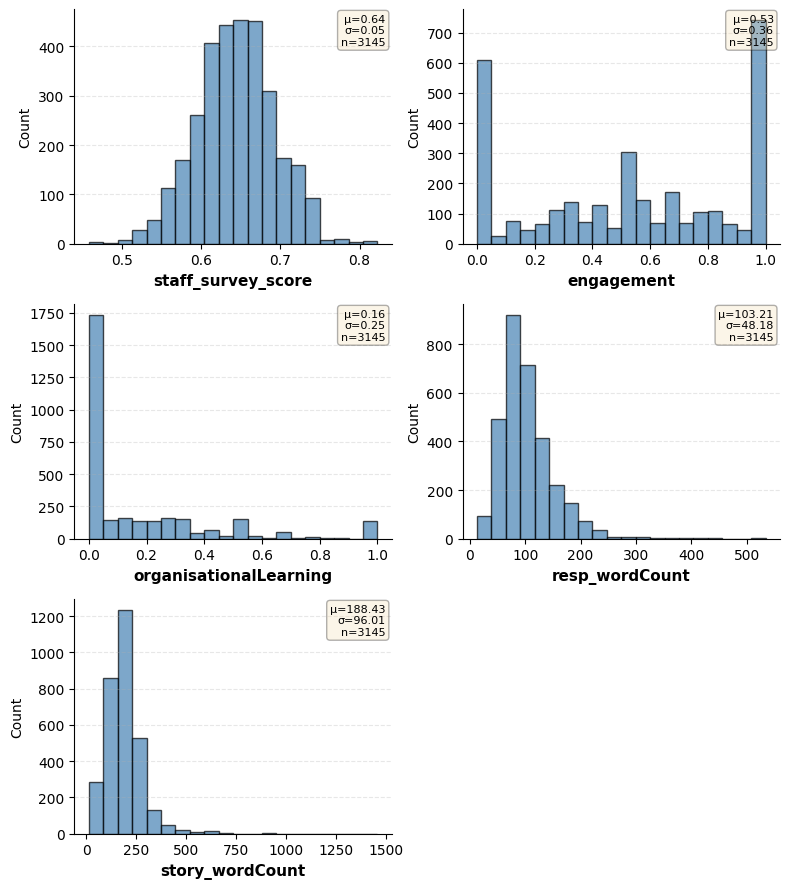

In [50]:
# Histogram of variables
histogram_grid(group_cdf_ss,['staff_survey_score',
                          'engagement', 
                          'organisationalLearning', 
                          'resp_wordCount',
                          'story_wordCount',
                          ], ncols =2)

In [91]:
# Check that the wordcounts are significantly different from each other
group_cdf_ss['wc_diff'] = group_cdf_ss['resp_wordCount'] - group_cdf_ss['story_wordCount']

print(f"Mean difference: {group_cdf_ss['wc_diff'].mean():.1f} words")
print(f"Responses longer than complaints: {(group_cdf_ss['wc_diff'] > 0).mean():.1%}")
stat, p_value = stats.wilcoxon(group_cdf_ss['story_wordCount'], group_cdf_ss['resp_wordCount'])

n = len(group_cdf_ss['story_wordCount'])
z_score = (stat - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)

# Effect size (r = Z / sqrt(N))
r = abs(z_score) / np.sqrt(n)

print(f"W = {stat}, Z = {z_score:.2f}, p = {p_value:.3f}, r = {r:.2f}")

Mean difference: -85.2 words
Responses longer than complaints: 16.2%
W = 439811.0, Z = -39.93, p = 0.000, r = 0.71


The organisational level descriptives roughly match those at the trust level, indicating the variables do not vary considerably at different levels of scale.

## 3.3 Staff survey predictions


The correlation matrix below extends the analysis to include the composite staff survey score, examining associations between corrective culture indicators and the staff survey measure at the organisation-year level.

In [93]:
corvars2 = ['staff_survey_score',
 'year',
 'story_wordCount',
 'resp_wordCount',
 'engagement',
 'organisationalLearning']

In [94]:
corr_with_sig(group_cdf_ss[corvars2].dropna())

,staff_survey_score,year,story_wordCount,resp_wordCount,engagement,organisationalLearning
staff_survey_score,1.00,0.11***,-0.01,0.08***,0.09***,-0.01
year,0.11***,1.00,-0.19***,0.08***,-0.01,-0.08***
story_wordCount,-0.01,-0.19***,1.00,0.08***,-0.12***,0.11***
resp_wordCount,0.08***,0.08***,0.08***,1.00,0.46***,0.31***
engagement,0.09***,-0.01,-0.12***,0.46***,1.00,0.41***
organisationalLearning,-0.01,-0.08***,0.11***,0.31***,0.41***,1.00


At the organisation-year level, the composite staff survey score shows small but significant positive correlations with year (r = 0.11, p < .001), response word count (r = 0.08, p < .001), and engagement (r = 0.09, p < .001). The correlation between the staff survey score and organisational learning was not statistically significant (r = -0.01). It should be noted that all significant correlations are very small.

### 3.3.1 Mixed effects model selection

In [54]:

ols_model_ss = smf.ols("staff_survey_score ~ 1", data=group_cdf_ss).fit()
me_model_ss = sm.MixedLM.from_formula(
    formula="staff_survey_score ~ 1",
    data=group_cdf_ss,
    re_formula="1", 
    groups="org_idx"
).fit(reml=False) # REML used by default, meaning you cant compare - use ML instead to make comparable with OLS
me_model2_ss = sm.MixedLM.from_formula(
    formula="staff_survey_score ~ 1",
    data=group_cdf_ss,
    re_formula="1",  
    groups="trust_idx"
).fit(reml=False)

In [55]:
print(f"Log-Likelihood OLS regression: {ols_model_ss.llf:.2f}")
print(f"Log-Likelihood Mixed Effects Model (organisation as grouping): {me_model_ss.llf:.2f}")
print(f"Log-Likelihood Mixed Effects Model (trusts as grouping): {me_model2_ss.llf:.2f}")

Log-Likelihood OLS regression: 5038.02
Log-Likelihood Mixed Effects Model (organisation as grouping): 5803.26
Log-Likelihood Mixed Effects Model (trusts as grouping): 6439.60


Considerably higher log likelihood suggests that a mixed effects model is appropriate and that trusts are the most appropriate grouping variable. We can check this with a log likelihood test:

In [56]:
LR_stat = 2 * (me_model2_ss.llf - me_model_ss.llf)
df_diff = 2  # Adding slope variance + intercept-slope covariance

p_value = stats.chi2.sf(LR_stat, df=df_diff)
print(f"LR statistic: {LR_stat:.2f}, p = {p_value:.4f}")

LR statistic: 1272.66, p = 0.0000


The likelihood ratio test comparing the mixed effects model with organisations as the grouping variable (LL = 16664.17) to the model with trusts as the grouping variable (LL = 19771.26) was highly significant (LR = 6214.17, p < .0001, df = 2). The substantially higher log-likelihood for the trust-level model confirms that trusts are the more appropriate unit of clustering, and that the added complexity of trust-level random effects is well justified by the data. We therefore proceed with trusts as the grouping variable in all subsequent mixed effects models.

The intraclass correlation coefficient (ICC) is calculated to quantify the proportion of variance in staff survey scores attributable to between-trust differences.

In [57]:
# Calculate ICC
var_trust = me_model2_ss.cov_re.iloc[0, 0]
var_vc = sum(me_model2_ss.vcomp)
var_resid = me_model2_ss.scale
icc = var_trust / (var_trust + var_vc + var_resid)
print(f"ICC = {icc:.3f}")

ICC = 0.633


The ICC of 0.633 indicates that approximately 63.3% of the total variance in staff survey corrective culture scores is attributable to stable between-trust differences, with only 6.7% reflecting within-trust variation over time and across organisations. This high ICC confirms the importance of mixed effects modelling: ignoring the clustering of observations within trusts would substantially underestimate standard errors and inflate the risk of Type I errors in tests of predictor effects.

### 3.3.2 Controls model

The controls-only model (year and log complaint word count) is fitted first to establish a baseline against which the addition of the engagement and organisational learning predictors can be assessed.

In [58]:
# First need to centre the year variable
group_cdf_ss["year_c"] = group_cdf_ss["year"] - group_cdf_ss["year"].min()
formula = "staff_survey_score ~ year_c + story_wordCount_log"
controlsModel_ss = sm.MixedLM.from_formula(
        formula=formula,
        data=group_cdf_ss,
        re_formula="1",
        groups='trust_idx'
    ).fit()

In [59]:
print(controlsModel_ss.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: staff_survey_score
No. Observations: 3145    Method:             REML              
No. Groups:       104     Scale:              0.0008            
Min. group size:  10      Log-Likelihood:     6481.5075         
Max. group size:  68      Converged:          Yes               
Mean group size:  30.2                                          
----------------------------------------------------------------
                       Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.631    0.007 94.053 0.000  0.618  0.644
year_c                 0.002    0.000 11.010 0.000  0.002  0.003
story_wordCount_log    0.001    0.001  0.609 0.542 -0.001  0.003
trust_idx Var          0.002    0.008                           



In [60]:
print(f"Log-Likelihood: {controlsModel_ss.llf:.2f}")
aic, bic, n_params = calculate_aic_bic(controlsModel_ss)
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")

Log-Likelihood: 6481.51
AIC: -12953.02
BIC: -12922.75


<Figure size 640x480 with 0 Axes>

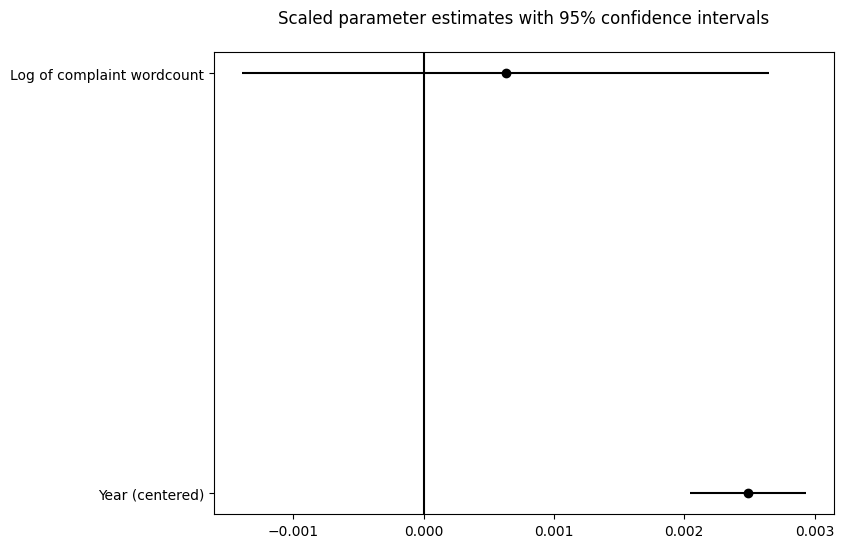

In [61]:
# rename variables
rename_cols = {'year_c': 'Year (centered)',
               'story_wordCount_log': 'Log of complaint wordcount',
               }

coefPlot(controlsModel_ss, rename_cols, figsize=(8, 6))
plt.show()

### 3.3.3 Exploring predictors of corrective culture

In [62]:
controls = "year_c + story_wordCount_log"
models_to_test = [controls,
                  controls + " + engagement",
                  controls + " + organisationalLearning",
                  controls + " + resp_wordCount_log"]

result_df, coef_df, pval_df = test_models(group_cdf_ss, models_to_test, target = "staff_survey_score", groups="trust_idx")

In [63]:
result_df.round(2)

,Models,n_params,AIC,BIC,Log_Likelihood,delta_AIC
0,year_c + story_wordCount_log,4,-12953.02,-12922.75,6481.51,0.00
1,year_c + story_wordCount_log + resp_wordCount_log,5,-12944.23,-12907.91,6478.12,8.78
2,year_c + story_wordCount_log + organisationalL...,5,-12942.06,-12905.74,6477.03,10.95
3,year_c + story_wordCount_log + engagement,5,-12940.14,-12903.82,6476.07,12.88


Model comparison using AIC indicates that the controls-only model provides the best fit to the data (AIC = −12953.02; ΔAIC = 0). Adding engagement (ΔAIC = 12.88), organisationalLearning (ΔAIC = 10.95), or log response word count (ΔAIC = 8.78) all produced worse AIC values, indicating that none of these predictors improve upon the controls-only baseline after penalising for the additional parameter. Consistently, individual model coefficients for engagement (β = 0.000, p = .810) and organisationalLearning (β = −0.003, p = .237) were not statistically significant. Response word count reached significance within its individual model (β = 0.003, p = .039) but the overall model fit remained inferior to the controls specification, suggesting the effect is too small to improve global model fit.

In [64]:
create_coef_pval_table(coef_df, pval_df)

,year_c,story_wordCount_log,engagement,organisationalLearning,resp_wordCount_log
year_c + story_wordCount_log,0.0025***,0.0006,,,
year_c + story_wordCount_log + engagement,0.0025***,0.0007,0.0004,,
year_c + story_wordCount_log + organisationalLearning,0.0025***,0.0006,,-0.0027,
year_c + story_wordCount_log + resp_wordCount_log,0.0024***,0.0003,,,0.0033*


In [65]:
formula = "staff_survey_score ~ year_c + story_wordCount_log + engagement"
engagementModel_ss = sm.MixedLM.from_formula(
        formula=formula,
        data=group_cdf_ss,
        re_formula="1",
        groups='trust_idx'
    ).fit()
print(engagementModel_ss.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: staff_survey_score
No. Observations: 3145    Method:             REML              
No. Groups:       104     Scale:              0.0008            
Min. group size:  10      Log-Likelihood:     6476.0685         
Max. group size:  68      Converged:          Yes               
Mean group size:  30.2                                          
----------------------------------------------------------------
                       Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.630    0.007 90.830 0.000  0.617  0.644
year_c                 0.002    0.000 11.003 0.000  0.002  0.003
story_wordCount_log    0.001    0.001  0.640 0.522 -0.001  0.003
engagement             0.000    0.002  0.241 0.810 -0.003  0.004
trust_idx Var          0.002    0.008                           



<Figure size 640x480 with 0 Axes>

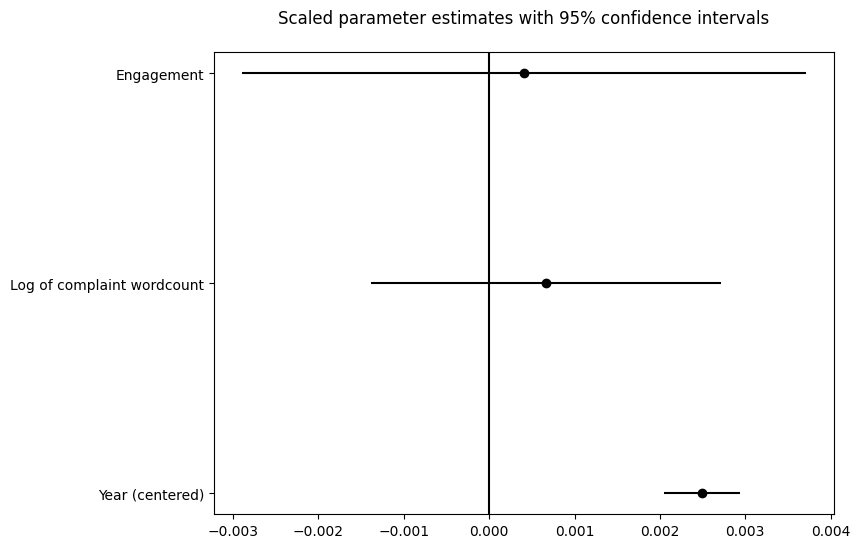

In [66]:
# rename variables
rename_cols = {'year_c': 'Year (centered)',
               'story_wordCount_log': 'Log of complaint wordcount',
               'engagement': 'Engagement',
               }

coefPlot(engagementModel_ss, rename_cols, figsize=(8, 6))
plt.show()

In [67]:
formula = "staff_survey_score ~ year_c + story_wordCount_log + organisationalLearning"
orgLearnModel_ss = sm.MixedLM.from_formula(
        formula=formula,
        data=group_cdf_ss,
        re_formula="1",
        groups='trust_idx'
    ).fit()
print(orgLearnModel_ss.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: staff_survey_score
No. Observations:  3145    Method:             REML              
No. Groups:        104     Scale:              0.0008            
Min. group size:   10      Log-Likelihood:     6477.0325         
Max. group size:   68      Converged:          Yes               
Mean group size:   30.2                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.631    0.007 93.958 0.000  0.618  0.644
year_c                  0.002    0.000 10.974 0.000  0.002  0.003
story_wordCount_log     0.001    0.001  0.617 0.537 -0.001  0.003
organisationalLearning -0.003    0.002 -1.182 0.237 -0.007  0.002
trust_idx Var           0.002    0.008                           



<Figure size 640x480 with 0 Axes>

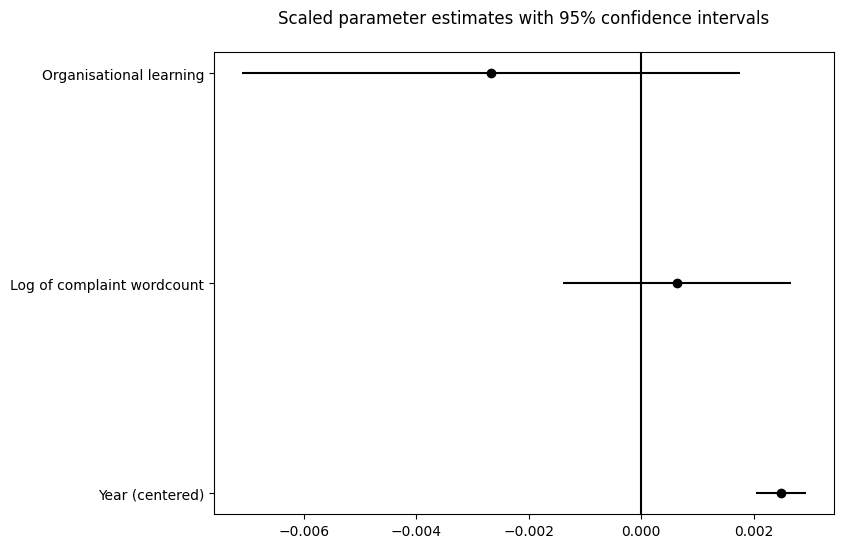

In [68]:
# rename variables
rename_cols = {'year_c': 'Year (centered)',
               'story_wordCount_log': 'Log of complaint wordcount',
               'organisationalLearning': 'Organisational learning',
               }

coefPlot(orgLearnModel_ss, rename_cols, figsize=(8, 6))
plt.show()

In [69]:
formula = "staff_survey_score ~ year_c + story_wordCount_log + resp_wordCount_log"
wcModel_ss = sm.MixedLM.from_formula(
        formula=formula,
        data=group_cdf_ss,
        re_formula="1",
        groups='trust_idx'
    ).fit()
print(wcModel_ss.summary())

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: staff_survey_score
No. Observations: 3145    Method:             REML              
No. Groups:       104     Scale:              0.0008            
Min. group size:  10      Log-Likelihood:     6478.1157         
Max. group size:  68      Converged:          Yes               
Mean group size:  30.2                                          
----------------------------------------------------------------
                       Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.618    0.009 67.187 0.000  0.600  0.636
year_c                 0.002    0.000 10.789 0.000  0.002  0.003
story_wordCount_log    0.000    0.001  0.284 0.777 -0.002  0.002
resp_wordCount_log     0.003    0.002  2.064 0.039  0.000  0.006
trust_idx Var          0.002    0.008                           



<Figure size 640x480 with 0 Axes>

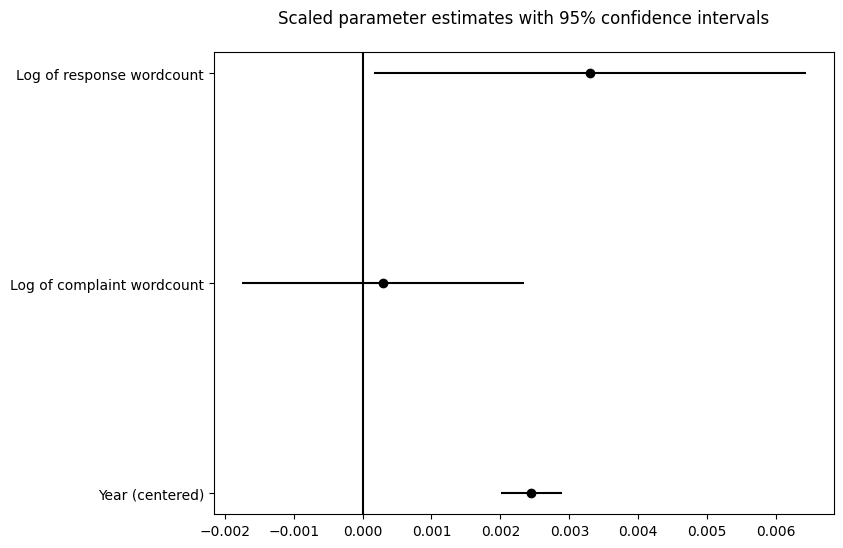

In [70]:
# rename variables
rename_cols = {'year_c': 'Year (centered)',
               'story_wordCount_log': 'Log of complaint wordcount',
               'resp_wordCount_log': 'Log of response wordcount',
               }

coefPlot(wcModel_ss, rename_cols, figsize=(8, 6))
plt.show()

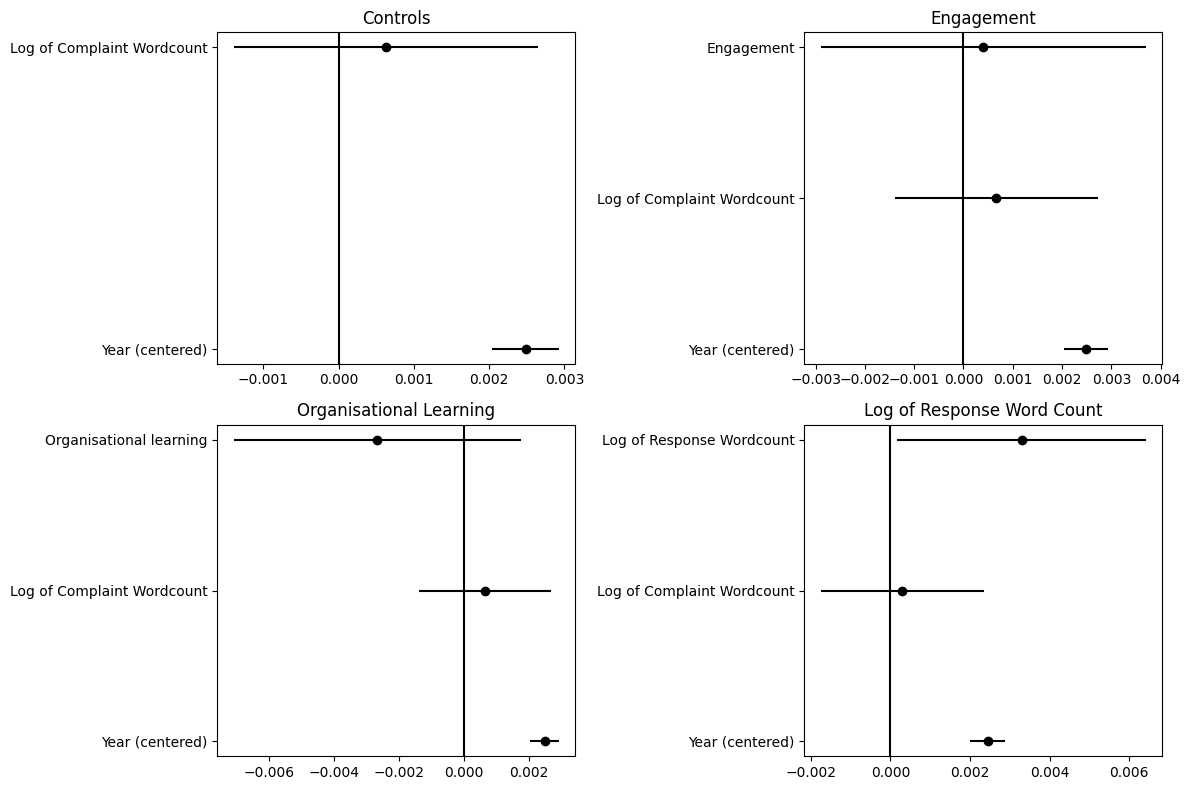

In [71]:
models = [controlsModel_ss, engagementModel_ss, orgLearnModel_ss, wcModel_ss]
titles = ['Controls', 'Engagement', 'Organisational Learning', 'Log of Response Word Count']
rename_dict = {'year_c': 'Year (centered)',
               'story_wordCount_log': 'Log of Complaint Wordcount',
               'engagement': 'Engagement',
               'organisationalLearning': 'Organisational learning',
               'resp_wordCount_log': 'Log of Response Wordcount',
               }
coefPlotGrid(models, titles, rename=rename_dict, save_file='coefficient_grid2.png')

The coefficient comparison across all four models confirms that year (centred) is the only consistent and significant predictor of the staff survey corrective culture score across all model specifications (β = 0.002, p < .001 throughout). Neither engagement nor organisational learning demonstrated a significant association with corrective culture after controlling for year and complaint length. Response word count was positively and significantly associated with the staff survey score in its respective model (β = 0.003, p = 0.039), though the overall model fit did not improve over the controls-only baseline and the effect was very small. Taken together, our engagement and organisational learning measures did not significantly predict the staff survey score at the organisation-year level.